# VPOD phylo-phenotype-balanced final model workflow

This notebook mirrors `main_vpod_wf.ipynb`, but inserts a balancing step before shallow-model training. The goal is to train final models on a subset that is balanced between vertebrate opsins (`Phylum == 'Chordata'`) and invertebrate opsins (`Phylum != 'Chordata'`) in three ways:

1. equal vertebrate/invertebrate counts;
2. comparable lambda_max range and bin representation;
3. reduced local phylogenetic redundancy when a matching tree is supplied.

The workflow is intentionally conservative: it down-samples the overrepresented side rather than changing model internals, so the downstream deepBreaks `model_compare_cv` and `finalize_top` calls remain almost identical to the main notebook.

## Imports

In [1]:
from pathlib import Path
import datetime
import shutil
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from deepBreaks.utils_alt2 import (
    get_models,
    get_best_aa_prop_combos,
    get_scores,
    get_params,
    make_pipeline,
)
from deepBreaks.preprocessing import (
    MisCare,
    ConstantCare,
    URareCare,
    CustomOneHotEncoder,
    AminoAcidPropertyEncoder,
    FeatureSelection,
    CollinearCare,
    read_data,
    write_fasta,
)
from deepBreaks.models import (
    model_compare_cv,
    finalize_top,
    importance_from_pipe,
    aaprop_importance_from_pipe,
    mean_importance,
    summarize_results,
)
from deepBreaks.visualization import (
    plot_scatter,
    dp_plot,
    dp_aa_prop_plot,
    plot_imp_model,
    plot_imp_all,
)

warnings.filterwarnings("ignore")
warnings.simplefilter("ignore")

## Locate workflow folders

This notebook is designed to live in `subtests/phylo_weighted_cv`. The next cell searches upward for `main_vpod_wf.ipynb`, then adds this subtest folder to `sys.path` so the balancing helper can be imported.

In [3]:
#cwd = Path.cwd().resolve()
#candidate_roots = [cwd, *cwd.parents]
#workflow_root = next(root for root in candidate_roots if (root / "main_vpod_wf.ipynb").exists())
#phylo_subtest_root = workflow_root / "subtests" / "phylo_weighted_cv"

#if str(phylo_subtest_root) not in sys.path:
#    sys.path.insert(0, str(phylo_subtest_root))

from vpod_scripts.phylo_balanced_sampling import (
    BalanceConfig,
    make_phylo_phenotype_balanced_subset,
    subset_training_matrix,
    write_balanced_subset_report,
)

#workflow_root, phylo_subtest_root

## User parameters

These mirror the main workflow parameters. The new section is `tree_file` and `balance_config`.

Important: for true phylogenetic de-redundancy, `tree_file` should be built from the same aligned FASTA IDs used for training. If `tree_file = None`, the notebook still balances group counts and lambda_max bins, but every row is treated as its own phylogenetic singleton.

In [35]:
# Data paths
path = "vpod_1.3_data_splits_2025-10-06_16-50-06"
seqFileName = f"{path}/wds_mnm_aligned_VPOD_1.3_het.fasta"
metaDataFileName = f"{path}/wds_mnm_meta.csv"

# Optional tree path. Replace None with a matching .treefile when available.
# Example: tree_file = workflow_root / "trees" / "vpod_1.3" / "wds_aligned_VPOD_1.3_het.fasta.treefile"
tree_file = None

# deepBreaks/model parameters
dataset = "wds"
use_gs_params = False
mt = "Lambda_Max"
use_ev = False
seq_type = "aa"
ana_type = "reg"
gap_threshold = 0.5
drop_ref = False
encoding_method = "aa_prop"  # "aa_prop" or "hot"
use_best_props = True

if use_best_props:
    props_to_keep = get_best_aa_prop_combos(dataset)
else:
    props_to_keep = ["H1", "H3", "NCI"]

if not use_gs_params:
    dataset = "ignore"

# Balancing parameters
balance_config = BalanceConfig(
    phenotype_col=mt,
    phylum_col="Phylum",
    vertebrate_phylum="Chordata",
    n_bins=10,
    range_mode="overlap",      # use only lambda_max range present in both groups
    bin_mode="equal_width",    # preserve wavelength-range coverage
    min_per_group_per_bin=1,
    max_per_group_per_bin=None,
    phylo_percentile=5.0,       # local tree-distance percentile for redundant-clade clusters
    random_state=7,
)

## Report directory

In [36]:
dt_label = datetime.datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
seqFile = seqFileName.split("/")[1]
seqFile = seqFile.split(".")[0] + "." + seqFile.split(".")[1]
gs_str = "_gs_opt" if use_gs_params else ""

if encoding_method == "hot":
    report_dir = Path(f"{seqFile}_phylo_balanced{gs_str}_{mt}_{dt_label}")
elif encoding_method == "aa_prop":
    props_used = "".join(["_" + prop for prop in props_to_keep])
    report_dir = Path(f"{seqFile}_phylo_balanced{props_used}{gs_str}_{mt}_{dt_label}")
else:
    raise ValueError("Encoding method not recognized")

report_dir.mkdir(parents=True, exist_ok=False)
report_dir

WindowsPath('wds_mnm_aligned_VPOD_1.3_het_phylo_balanced_H1_P2_SCT_Lambda_Max_2026-07-28_14-48-49')

## Read metadata and FASTA

This is the same loading pattern as the main workflow. The balancing happens after both objects are loaded, so the final selected IDs can be intersected with the gap-dropped sequence matrix.

In [37]:
print("reading meta-data")
meta_data = read_data(str(metaDataFileName), seq_type=None, is_main=False)

print("reading fasta file")
tr = read_data(str(seqFileName), seq_type=seq_type, is_main=True, gap_threshold=gap_threshold)

shutil.copy2(str(seqFileName), report_dir)
write_fasta(dat=tr, fasta_file=f"{seqFile}_gap_dropped.fasta", report_dir=str(report_dir))

print("metadata shape:", meta_data.shape)
print("sequence matrix shape:", tr.shape)

reading meta-data
reading fasta file
wds_mnm_aligned_VPOD_1.3_het_gap_dropped.fasta was saved successfully
metadata shape: (1724, 8)
sequence matrix shape: (1724, 354)


## Optional reference sequence handling

In [38]:
try:
    reference_seq = tr.loc["Bovine"].copy()
    ref_seq_name = "bovine"
except KeyError:
    reference_seq = tr.loc["Squid"].copy()
    ref_seq_name = "squid"

reference_seq.to_csv(path_or_buf=report_dir / "ref_sequence.csv", index=True, mode="w")

if drop_ref:
    tr = tr.drop(index=["Bovine", "Squid"], errors="ignore")
    meta_data = meta_data.drop(index=["Bovine", "Squid"], errors="ignore")

ref_seq_name

'bovine'

## Balance final training composition

This replaces the main notebook's direct `tr.merge(meta_data.loc[:, mt])` step. Instead, we use metadata to select a balanced set of IDs, then subset the sequence matrix and construct `y` from those selected rows.

Logic:

- Assign `vpod_balance_group = vertebrate` for Chordata and `invertebrate` otherwise.
- Define lambda_max bins across the shared vertebrate/invertebrate range (`range_mode='overlap'`).
- In each bin, sample the same number of vertebrate and invertebrate sequences: `min(n_vertebrate_bin, n_invertebrate_bin)`.
- If a tree is supplied, cluster locally similar tips at the requested tree-distance percentile and sample with inverse cluster-size weights, reducing the chance that a dense clade dominates a bin.

In [39]:
balance_result = make_phylo_phenotype_balanced_subset(
    meta_data=meta_data,
    tree_file=tree_file,
    config=balance_config,
)

balance_paths = write_balanced_subset_report(
    balance_result,
    out_dir=report_dir / "balanced_subset_audit",
    prefix="wds_phylo_phenotype_balanced",
)

pd.Series(balance_result.selection_summary, name="value")

tree_file                         None
phylo_threshold                   None
tree_matched_rows                    0
tree_missing_rows                 1724
n_selected                         628
n_selected_vertebrate              314
n_selected_invertebrate            314
n_bins_requested                    10
n_bins_used                         10
skipped_bins                        []
phenotype_min_selected           350.0
phenotype_max_selected           571.0
range_mode                     overlap
bin_mode                   equal_width
random_state                         7
Name: value, dtype: object

In [40]:
balance_result.bin_summary

vpod_balance_group,vpod_balance_bin,bin_left,bin_right,vertebrate,invertebrate,balanced_n_per_group
0,"(349.999, 372.1]",349.999,372.1,200,38,38
1,"(372.1, 394.2]",372.100,394.2,49,11,11
2,"(394.2, 416.3]",394.200,416.3,71,4,4
3,"(416.3, 438.4]",416.300,438.4,56,34,34
4,"(438.4, 460.5]",438.400,460.5,84,23,23
5,"(460.5, 482.6]",460.500,482.6,89,14,14
6,"(482.6, 504.7]",482.600,504.7,468,39,39
7,"(504.7, 526.8]",504.700,526.8,157,60,60
8,"(526.8, 548.9]",526.800,548.9,106,63,63
9,"(548.9, 571.0]",548.900,571.0,113,28,28


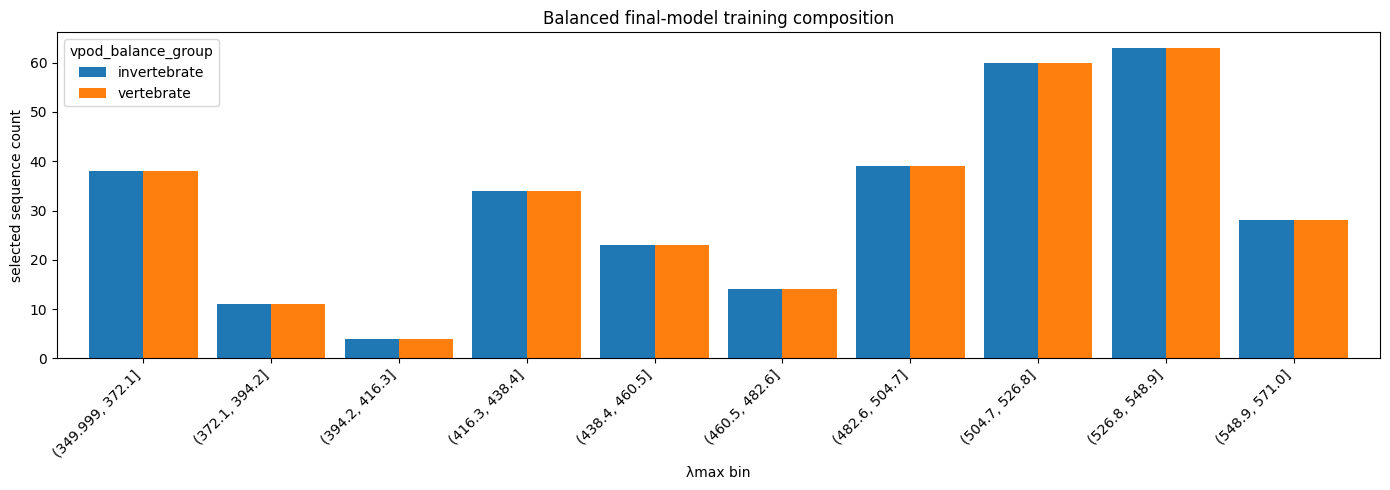

In [51]:
selected_counts = (
    balance_result.selected_meta
    .groupby(["vpod_balance_bin", "vpod_balance_group"], observed=True)
    .size()
    .unstack(fill_value=0)
)

ax = selected_counts.plot(kind="bar", figsize=(14, 5), width=0.85)
ax.set_xlabel("λmax bin")
ax.set_ylabel("selected sequence count")
ax.set_title("Balanced final-model training composition")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(report_dir / "balanced_subset_audit" / "selected_counts_by_lambda_bin.svg", format="svg")
plt.show()

## Create final `tr` and `y` objects

From this point forward, the variable names match the main workflow again: `tr` is the balanced sequence matrix, and `y` is the balanced phenotype vector.

In [42]:
tr, y, balanced_meta = subset_training_matrix(
    tr=tr,
    meta_data=meta_data,
    selected_ids=balance_result.selected_ids,
    phenotype_col=mt,
    use_ev=use_ev,
)

balanced_meta.to_csv(report_dir / "balanced_training_metadata.tsv", sep="\t", index=True)
write_fasta(dat=tr, fasta_file="balanced_training_gap_dropped.fasta", report_dir=str(report_dir))

print("Shape of balanced data is:", tr.shape)
print("Length of balanced y is:", len(y))
balanced_meta[[mt, "Phylum"]].head()

balanced_training_gap_dropped.fasta was saved successfully
Shape of balanced data is: (628, 354)
Length of balanced y is: 628


,Lambda_Max,Phylum
S834,358.0,Chordata
MNM1314,366.0,Chordata
S897,360.0,Chordata
S581,360.0,Chordata
S614,360.0,Chordata


## Preprocessing pipeline

In [43]:
def make_vpod_prep_pipeline(encoding_method, props_to_keep, ana_type, keep):
    if encoding_method == "hot":
        return make_pipeline(
            steps=[
                ("mc", MisCare(missing_threshold=0.05)),
                ("cc", ConstantCare()),
                ("ur", URareCare(threshold=0.01)),
                ("cc2", ConstantCare()),
                ("one_hot", CustomOneHotEncoder()),
                ("feature_selection", FeatureSelection(model_type=ana_type, alpha=0.10, keep=keep)),
                ("collinear_care", CollinearCare(dist_method="correlation", threshold=0.01, keep=keep)),
            ]
        )
    if encoding_method == "aa_prop":
        return make_pipeline(
            steps=[
                ("mc", MisCare(missing_threshold=0.05)),
                ("cc", ConstantCare()),
                ("aa_prop", AminoAcidPropertyEncoder(props_to_keep=props_to_keep)),
                ("feature_selection", FeatureSelection(model_type=ana_type, alpha=0.10, keep=keep)),
                ("collinear_care", CollinearCare(dist_method="correlation", threshold=0.01, keep=keep)),
            ]
        )
    raise ValueError("Encoding method not recognized")


prep_pipeline = make_vpod_prep_pipeline(
    encoding_method=encoding_method,
    props_to_keep=props_to_keep,
    ana_type=ana_type,
    keep=False,
)

## Compare shallow models on the balanced training set

In [44]:
%%time
report, top = model_compare_cv(
    X=tr,
    y=y,
    preprocess_pipe=prep_pipeline,
    models_dict=get_models(ana_type=ana_type, encoding=encoding_method, dataset=dataset),
    scoring=get_scores(ana_type=ana_type),
    report_dir=str(report_dir),
    cv=10,
    ana_type=ana_type,
    cache_dir=str(report_dir),
)
report

Fitting rf...
Fitting gbr...
Fitting BayesianRidge...
Fitting xgb...
CPU times: total: 6.33 s
Wall time: 40.8 s


,R2,MAE,MSE,RMSE,MAPE,SD,ASD
rf,0.919224,10.157089,312.174967,17.045300,0.022361,17.651629,14.446656
gbr,0.917784,11.199164,316.287377,17.362431,0.024633,17.771147,13.806213
xgb,0.903477,10.515462,371.143645,18.628146,0.023056,19.250473,16.131104
BayesianRidge,0.897414,13.460583,390.828721,19.552056,0.029743,19.762536,14.473946


## Finalize top models

This mirrors the main notebook: rebuild the preprocessing pipeline with `keep=True`, attach each winning model estimator, then call `finalize_top`.

In [45]:
prep_pipeline = make_vpod_prep_pipeline(
    encoding_method=encoding_method,
    props_to_keep=props_to_keep,
    ana_type=ana_type,
    keep=True,
)

modified_top = []
mtml = []
for model in top:
    modified_top.append(make_pipeline(steps=[("prep", prep_pipeline), model.steps[-1]]))
    model_name = str(model[1:]).split("'")[3]
    mtml.append(model_name)

mtml

['rf', 'gbr', 'xgb', 'BayesianRidge']

In [46]:
%%time
top = finalize_top(
    X=tr,
    y=y,
    top_models=modified_top,
    grid_param={},
    report_dir=str(report_dir),
    cv=10,
)

Tuning rf...
No Grid-Search Specified, fitting model to default parameters.
--- Best Model Performance on Training Data ---
Mean Absolute Error (MAE): 3.725
Root Mean Squared Error (RMSE): 6.343
R-squared (R2): 0.990
Standard Deviation of Abs. Prediction Error: 5.135
Tuning gbr...
No Grid-Search Specified, fitting model to default parameters.
--- Best Model Performance on Training Data ---
Mean Absolute Error (MAE): 6.936
Root Mean Squared Error (RMSE): 9.588
R-squared (R2): 0.977
Standard Deviation of Abs. Prediction Error: 6.620
Tuning xgb...
No Grid-Search Specified, fitting model to default parameters.
--- Best Model Performance on Training Data ---
Mean Absolute Error (MAE): 0.159
Root Mean Squared Error (RMSE): 0.348
R-squared (R2): 1.000
Standard Deviation of Abs. Prediction Error: 0.310
Tuning BayesianRidge...
No Grid-Search Specified, fitting model to default parameters.
--- Best Model Performance on Training Data ---
Mean Absolute Error (MAE): 9.376
Root Mean Squared Error (R

## Feature importance and summaries

In [47]:
try:
    mean_imp = mean_importance(top, report_dir=str(report_dir))
    summarize_results(top_models=top, report_dir=str(report_dir))
except Exception as exc:
    print("Importance summary failed; final model files may still have been written.")
    print(exc)

In [48]:
from vpod_scripts.translate_candidate_sts import translate_candidate_sts, translate_candidate_sts_aa_props

if encoding_method == 'hot':
    trans_imp_report = translate_candidate_sts(report_dir, ref_seq_name, reference_seq)
elif encoding_method == 'aa_prop':
    trans_imp_report = translate_candidate_sts_aa_props(report_dir, reference_seq, ref_seq_name)


rf Done
rf  Done
gbr Done
gbr  Done
xgb Done
xgb  Done
BayesianRidge Done
BayesianRidge  Done


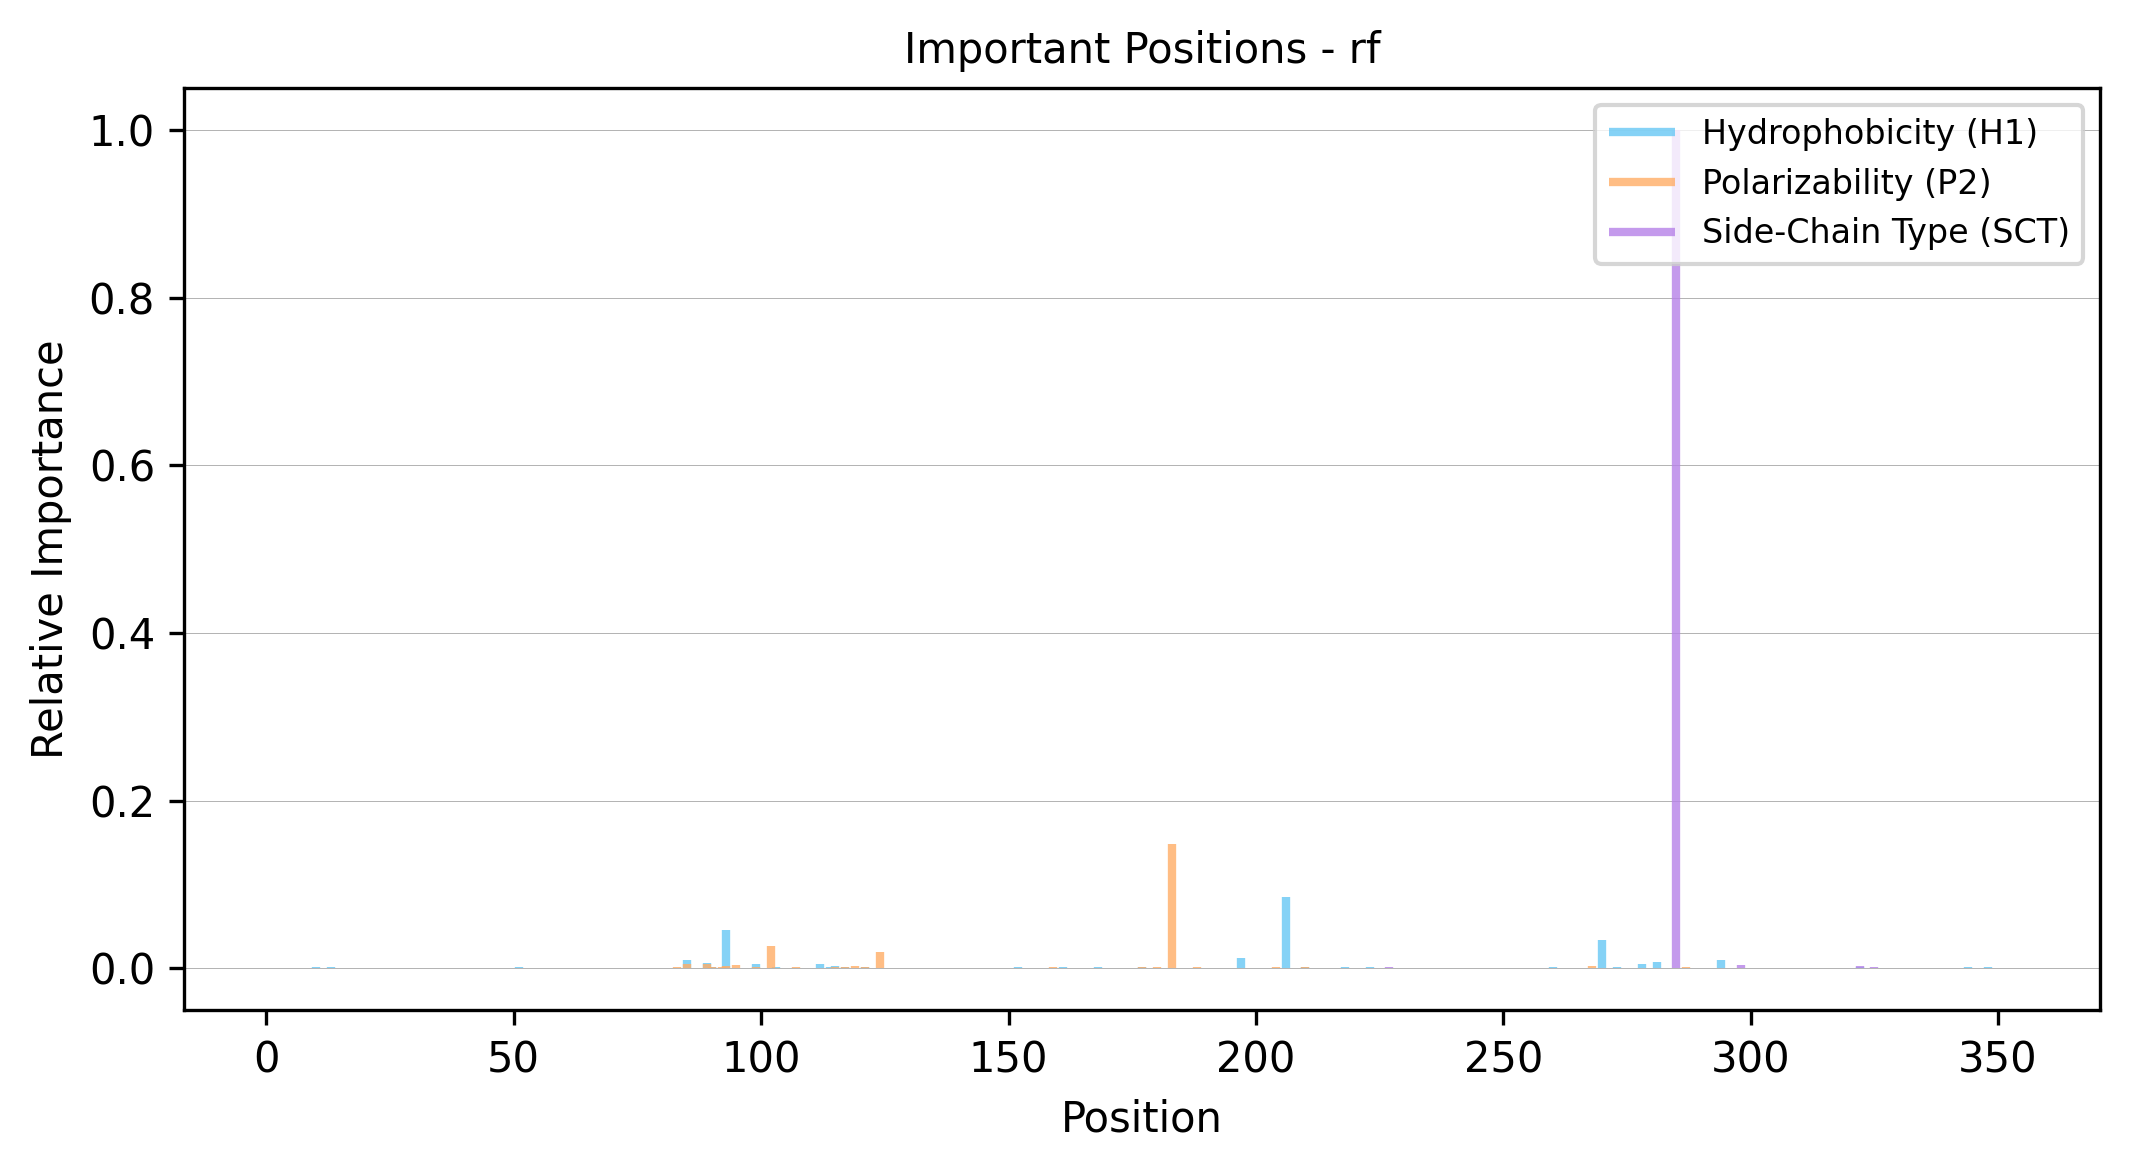

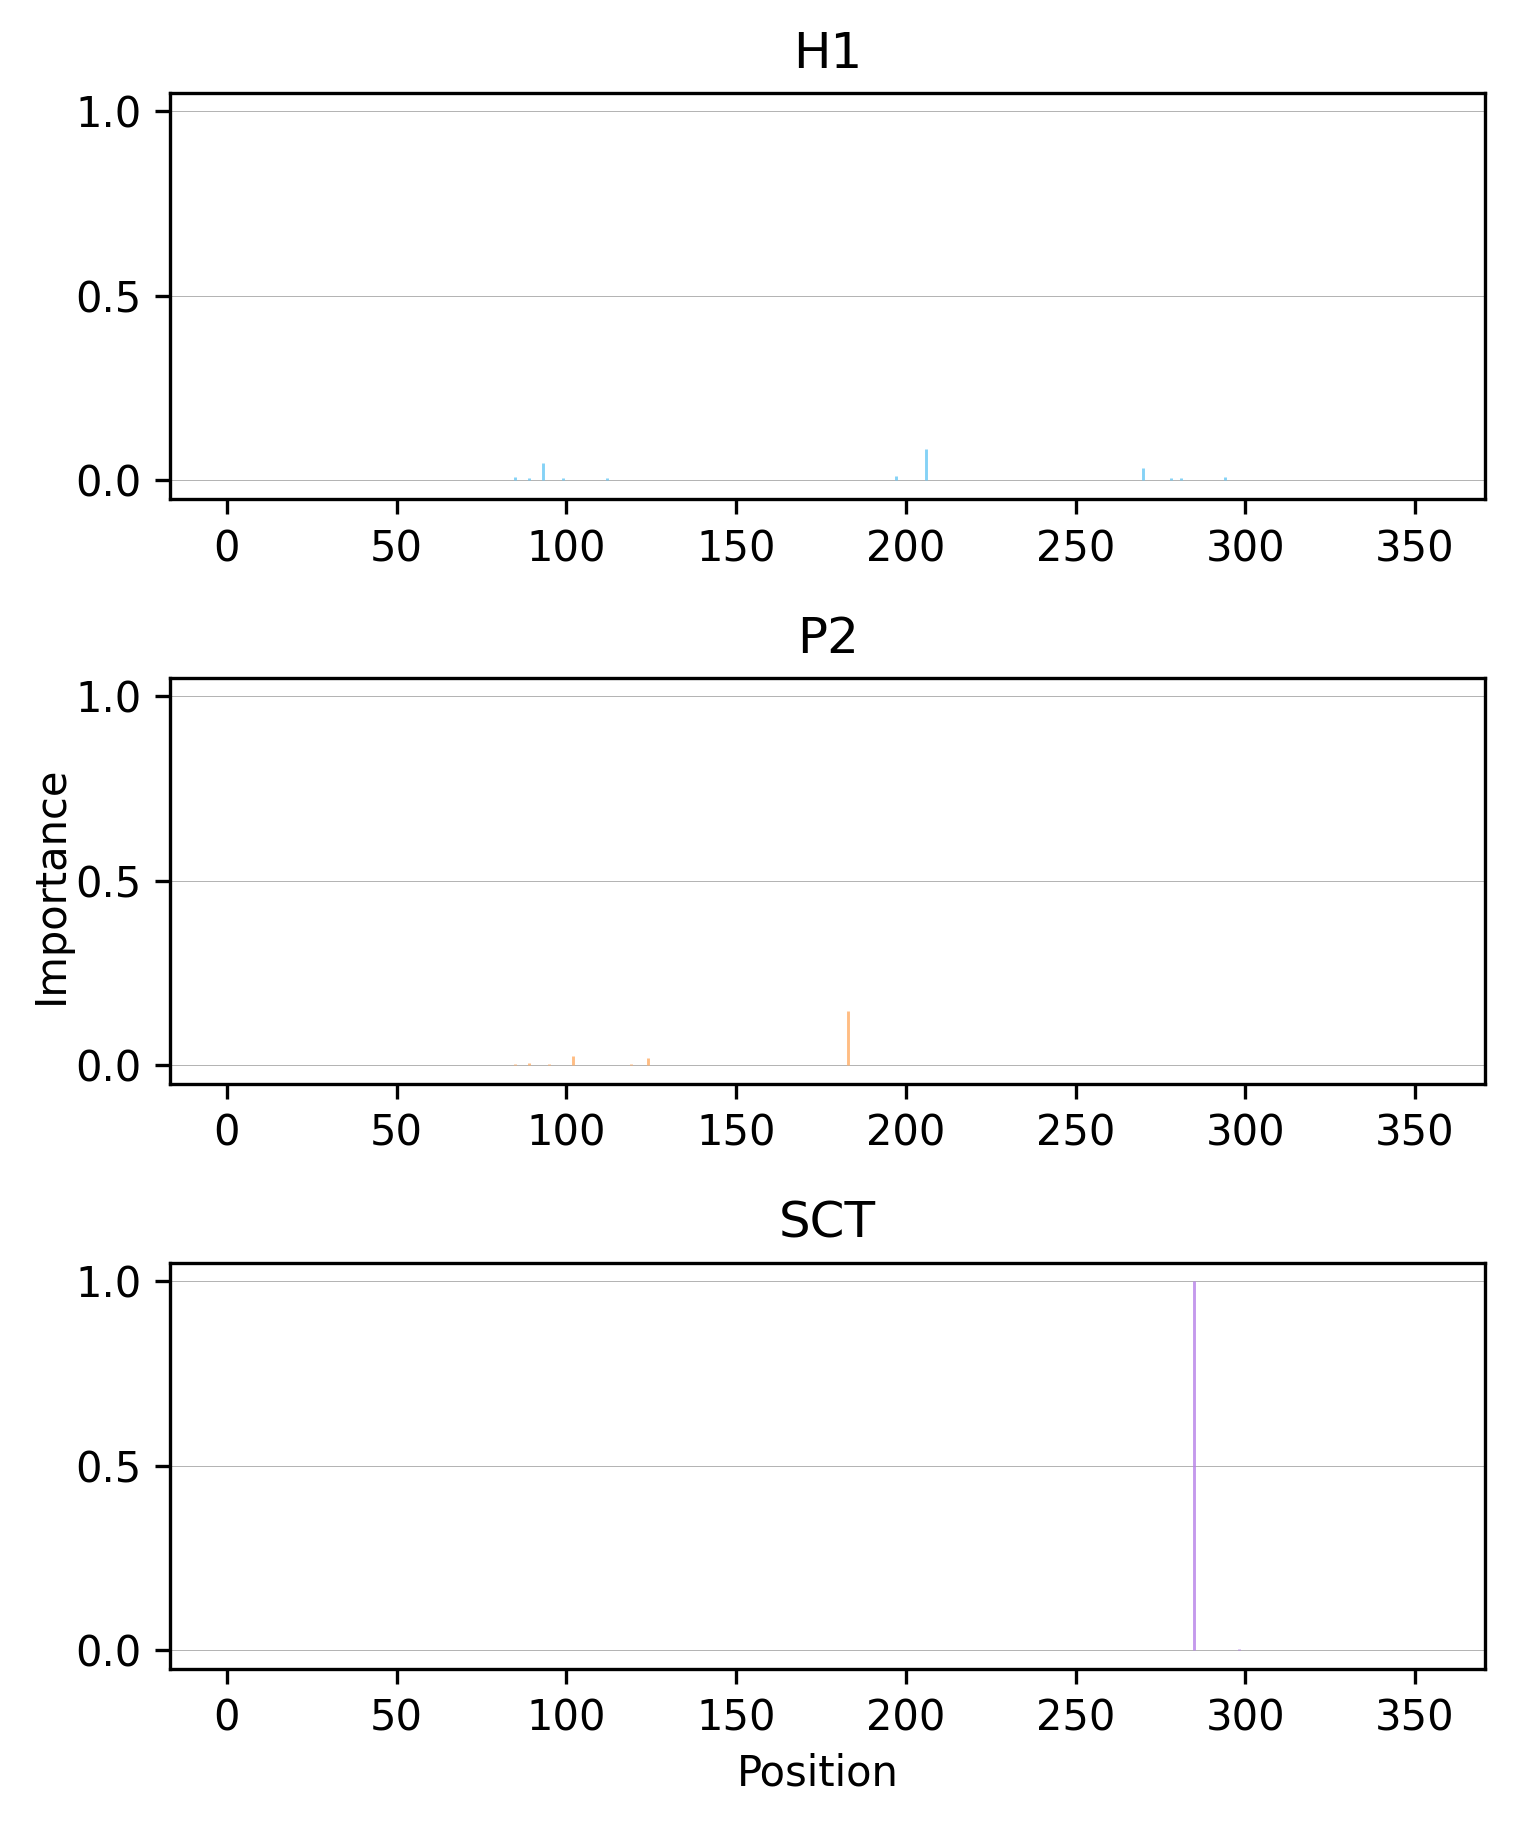

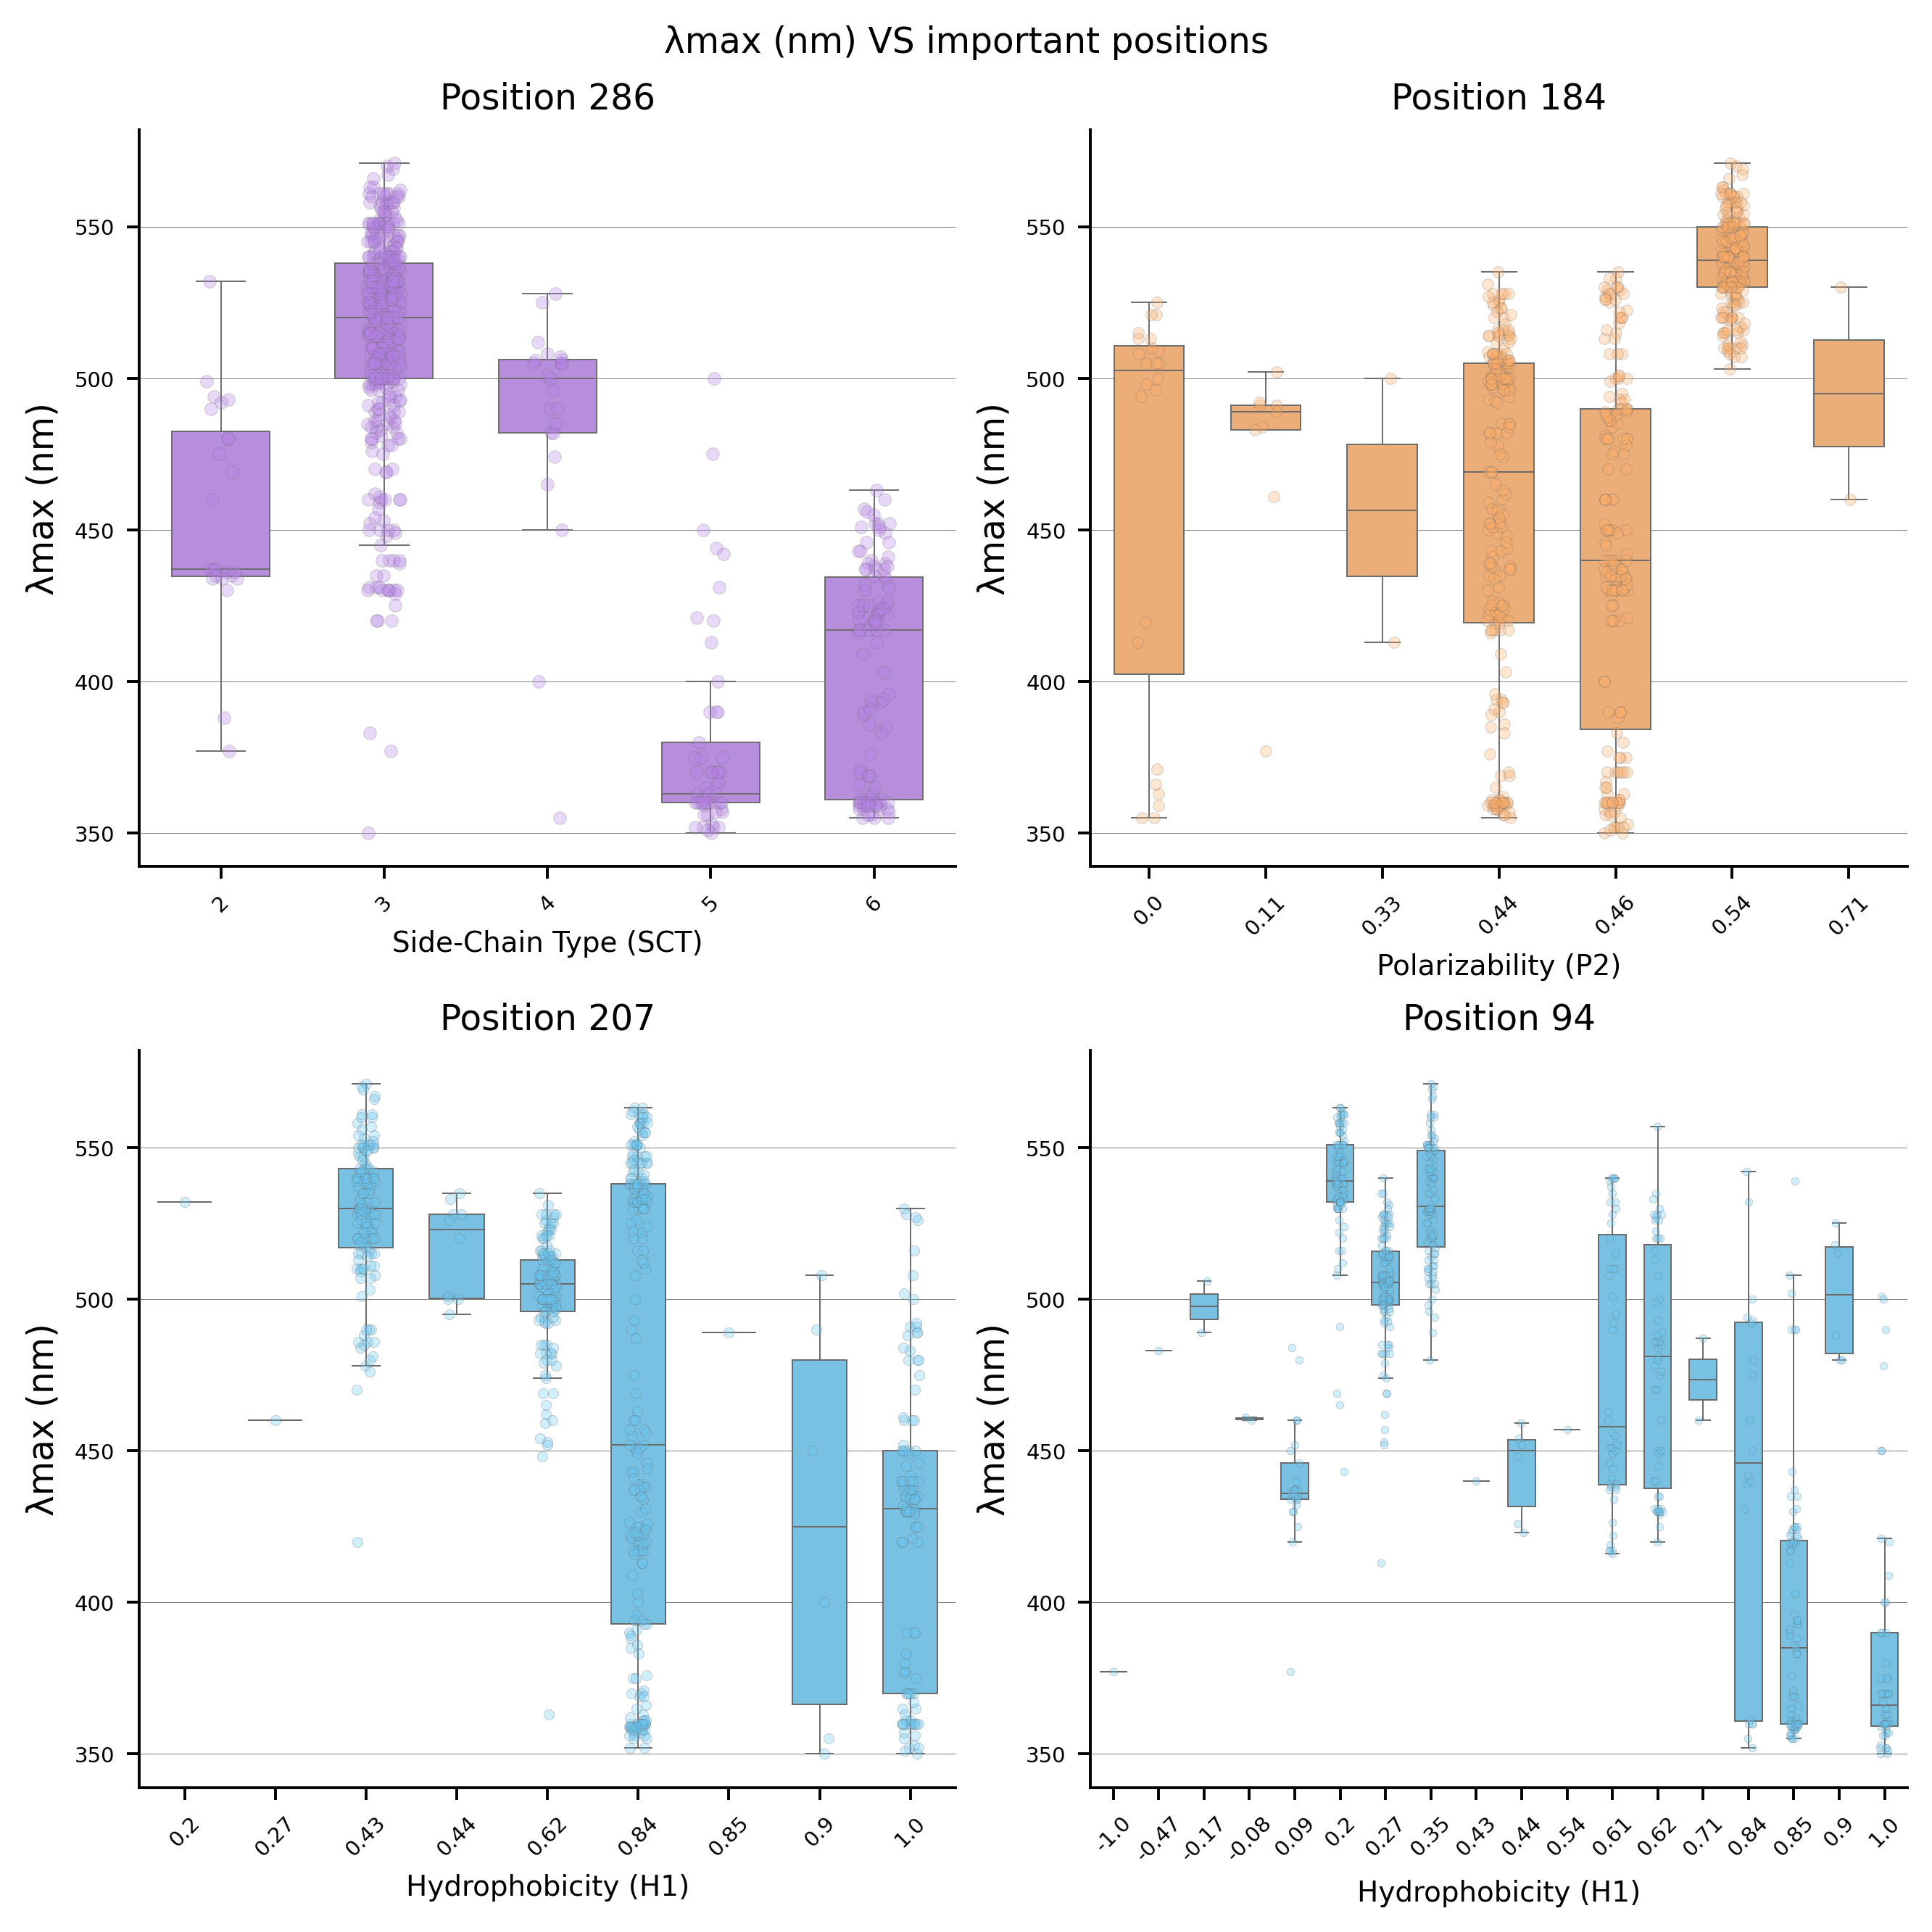

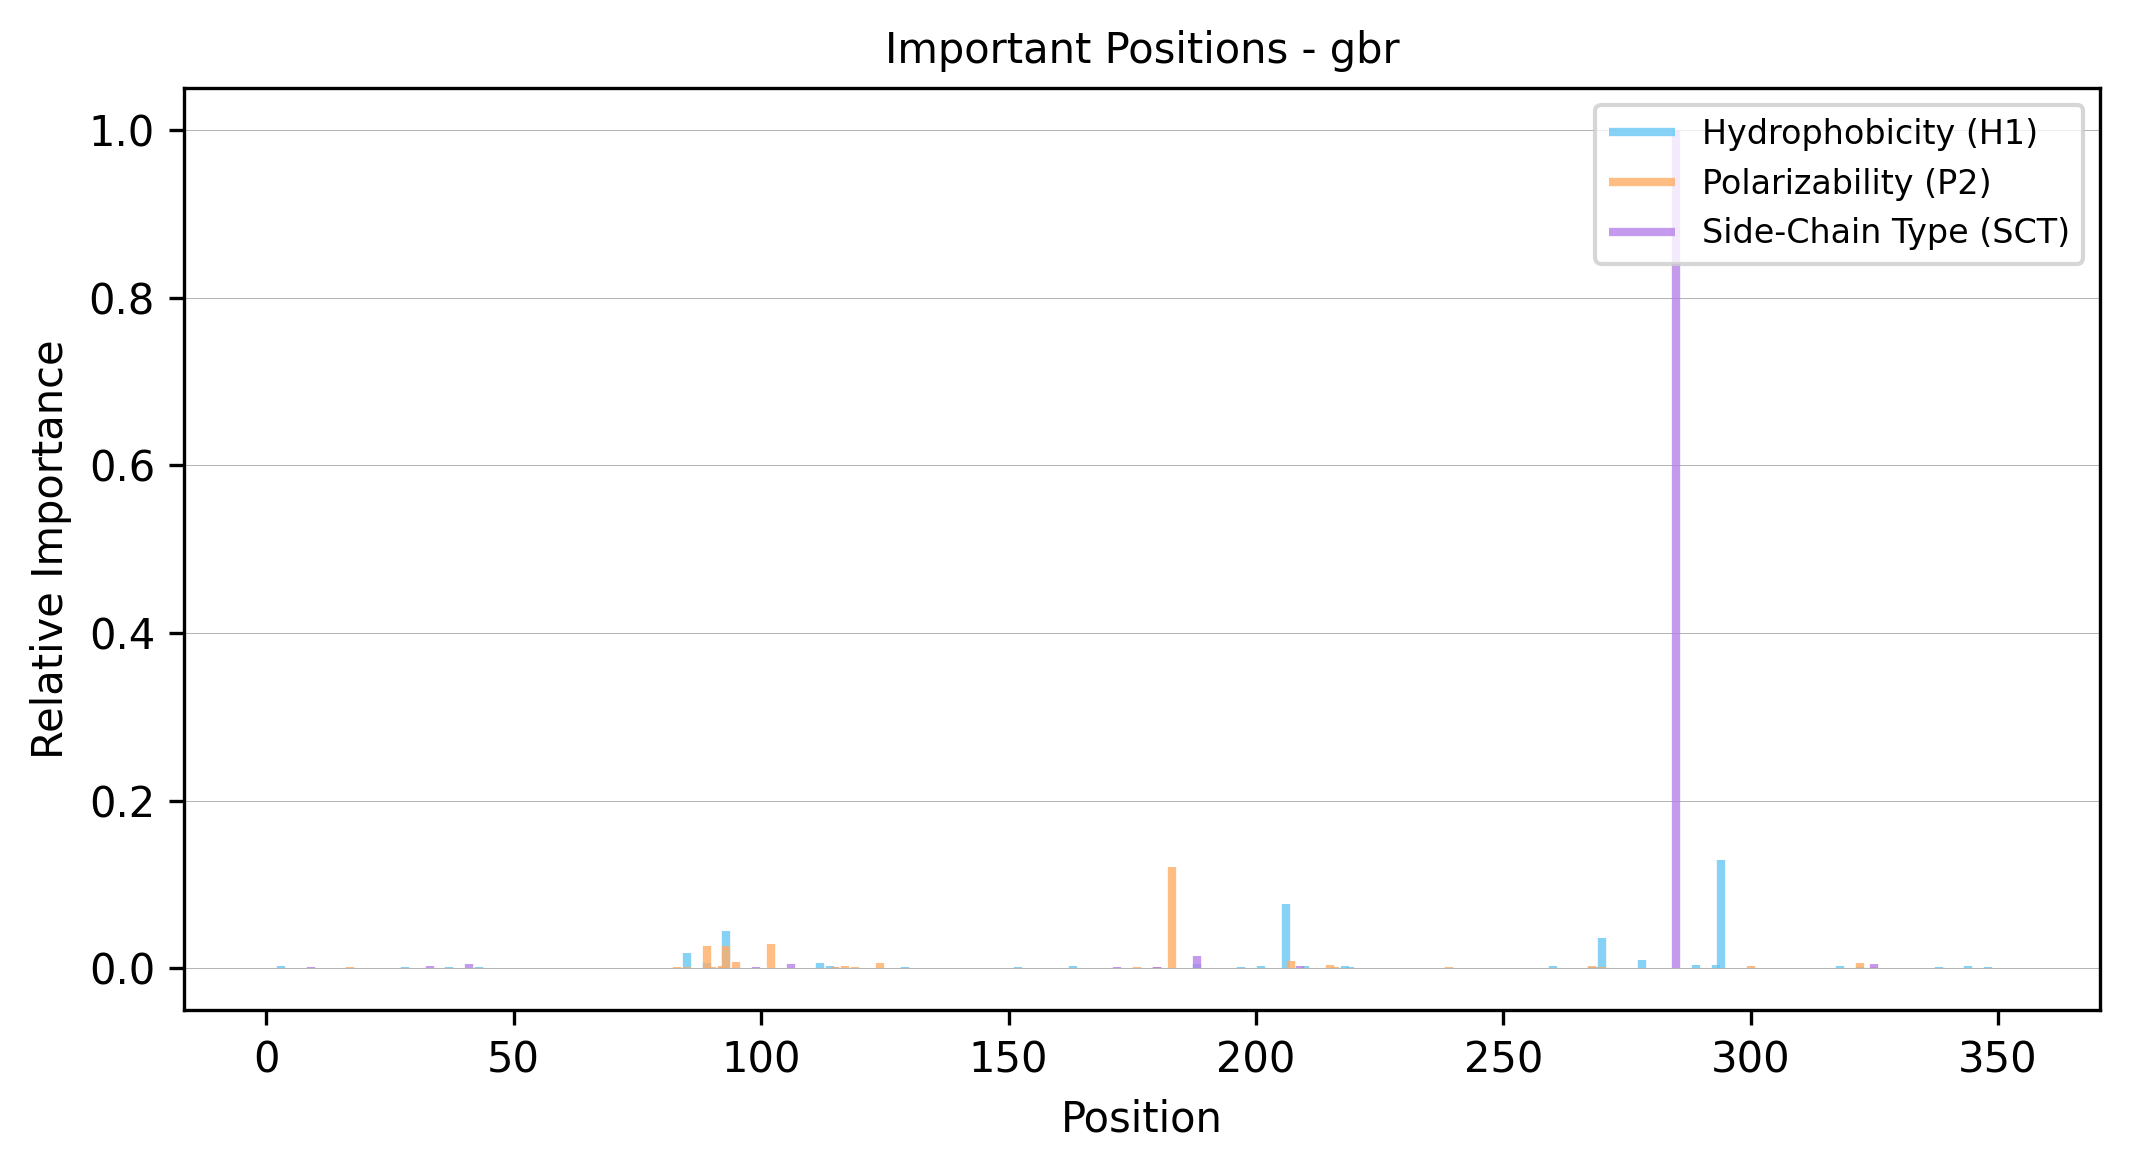

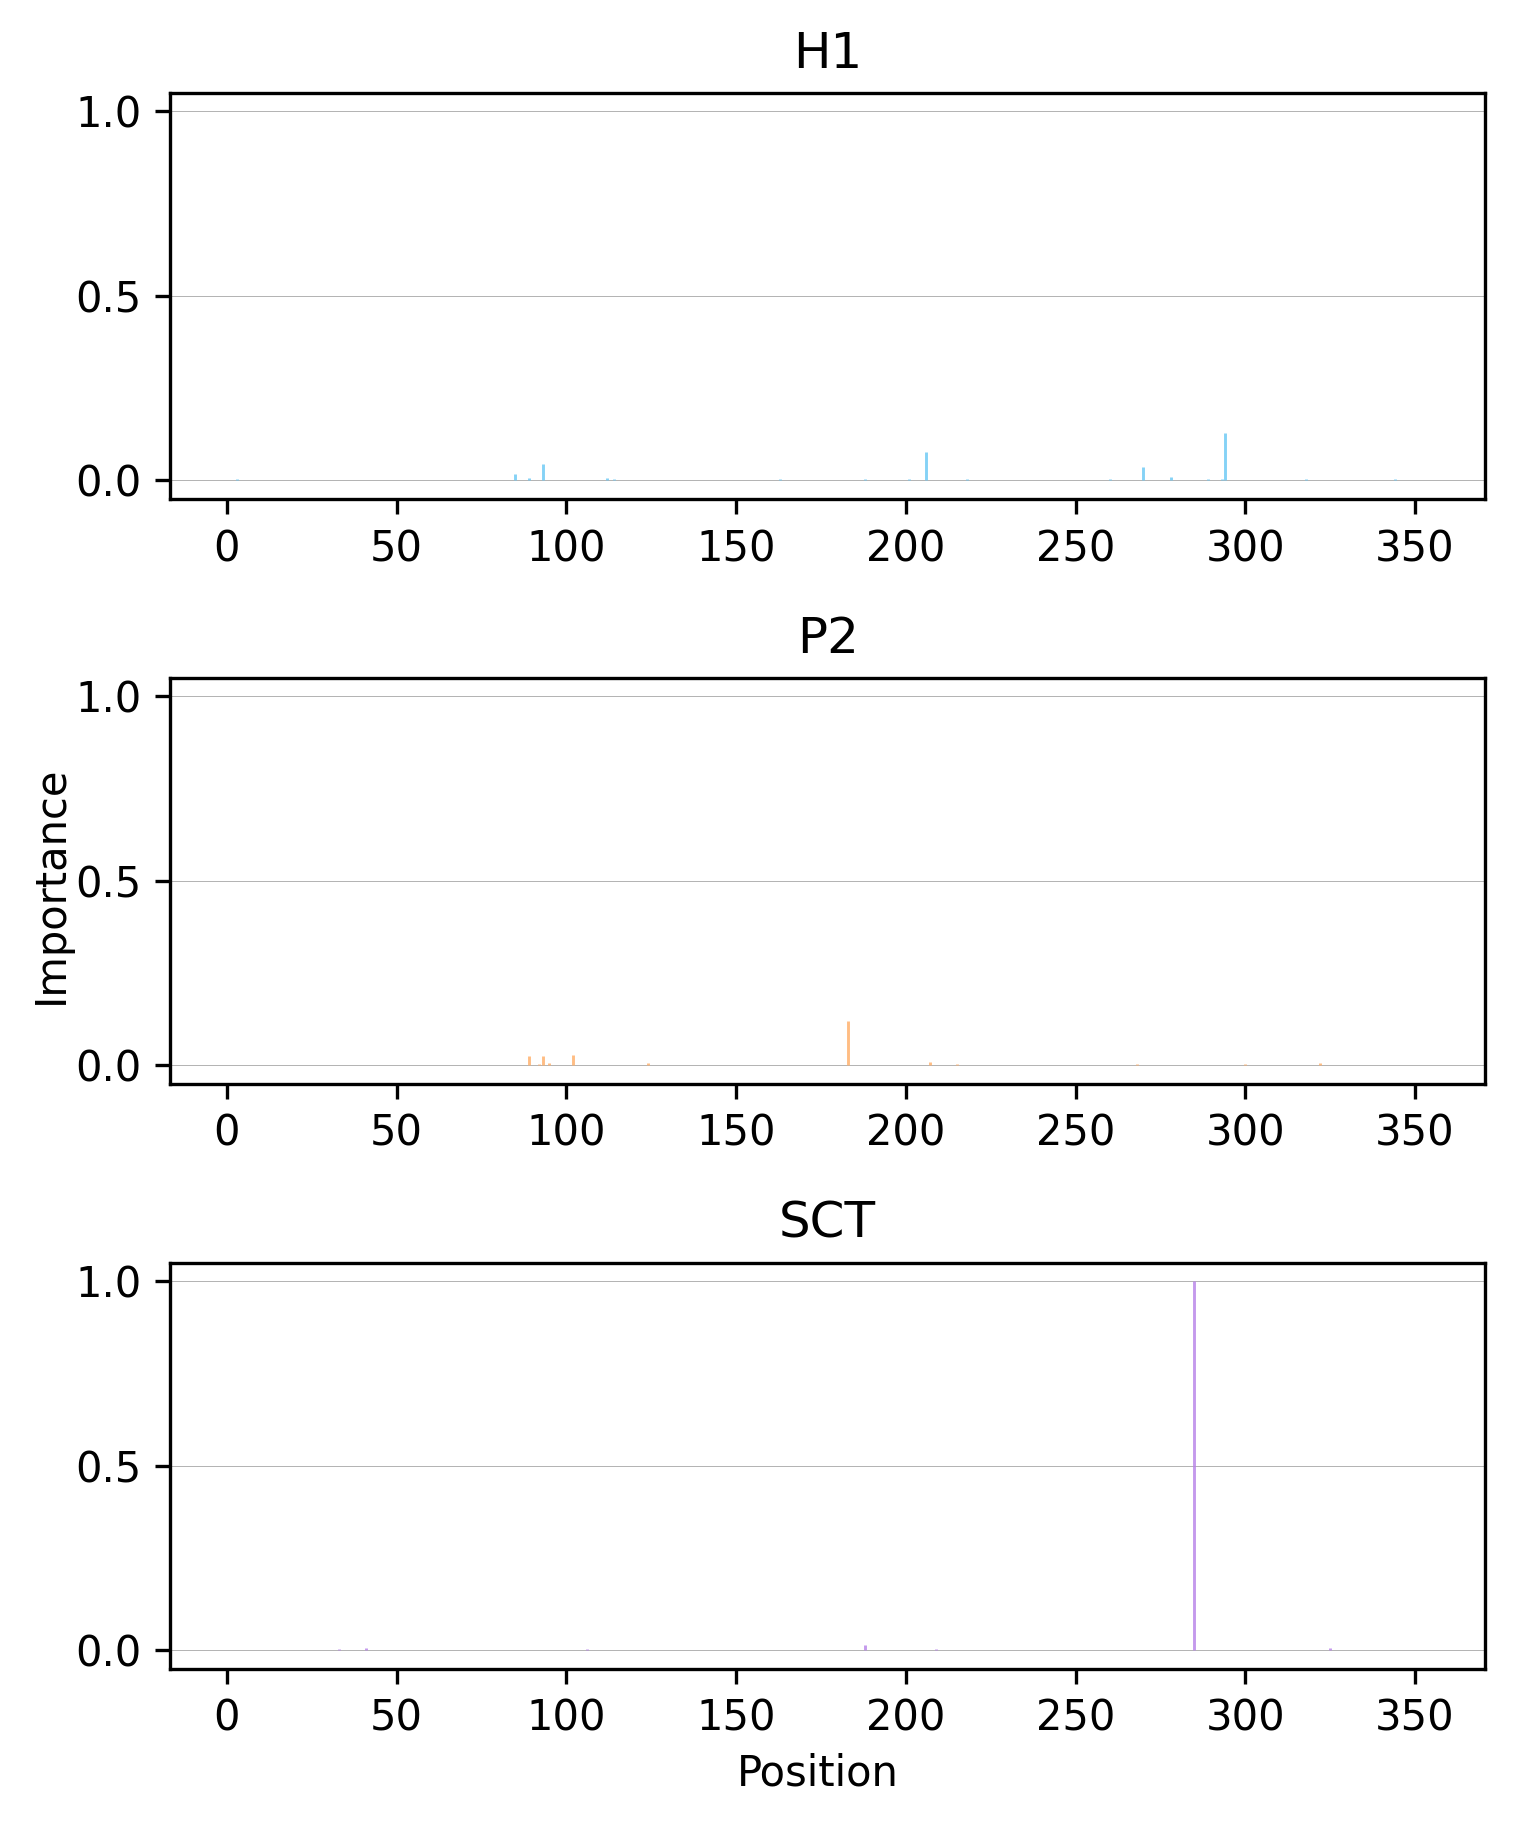

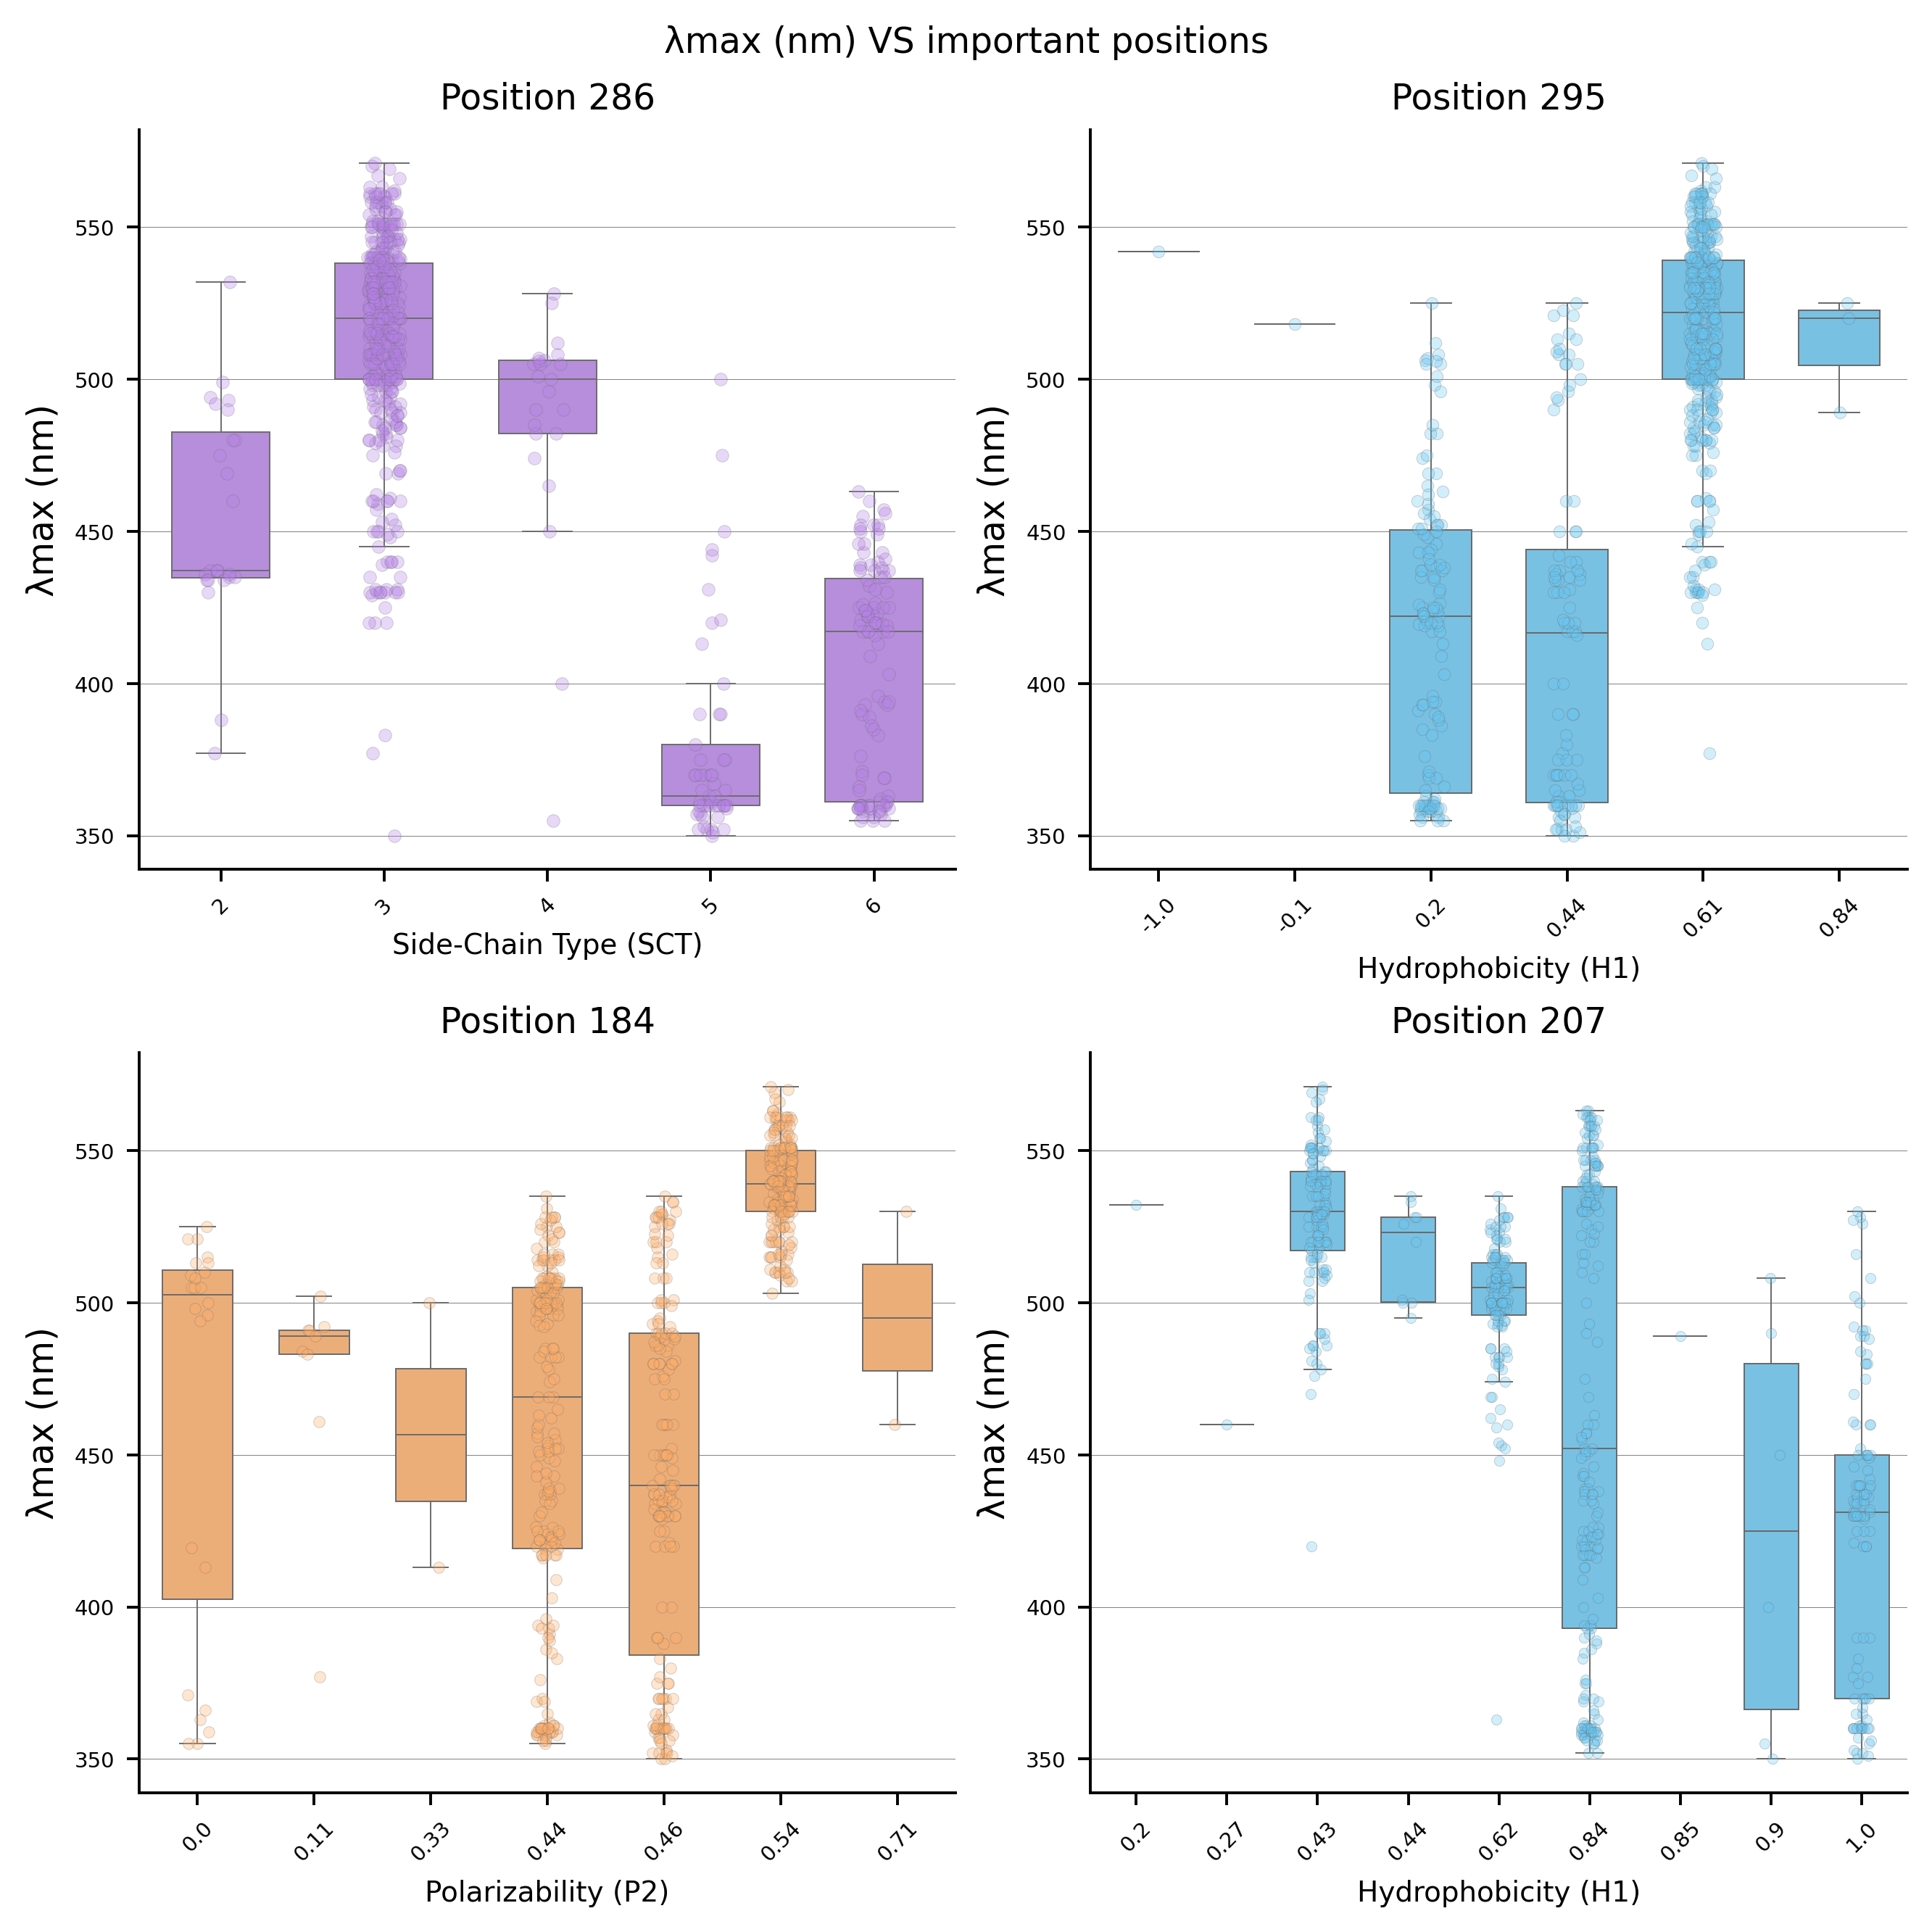

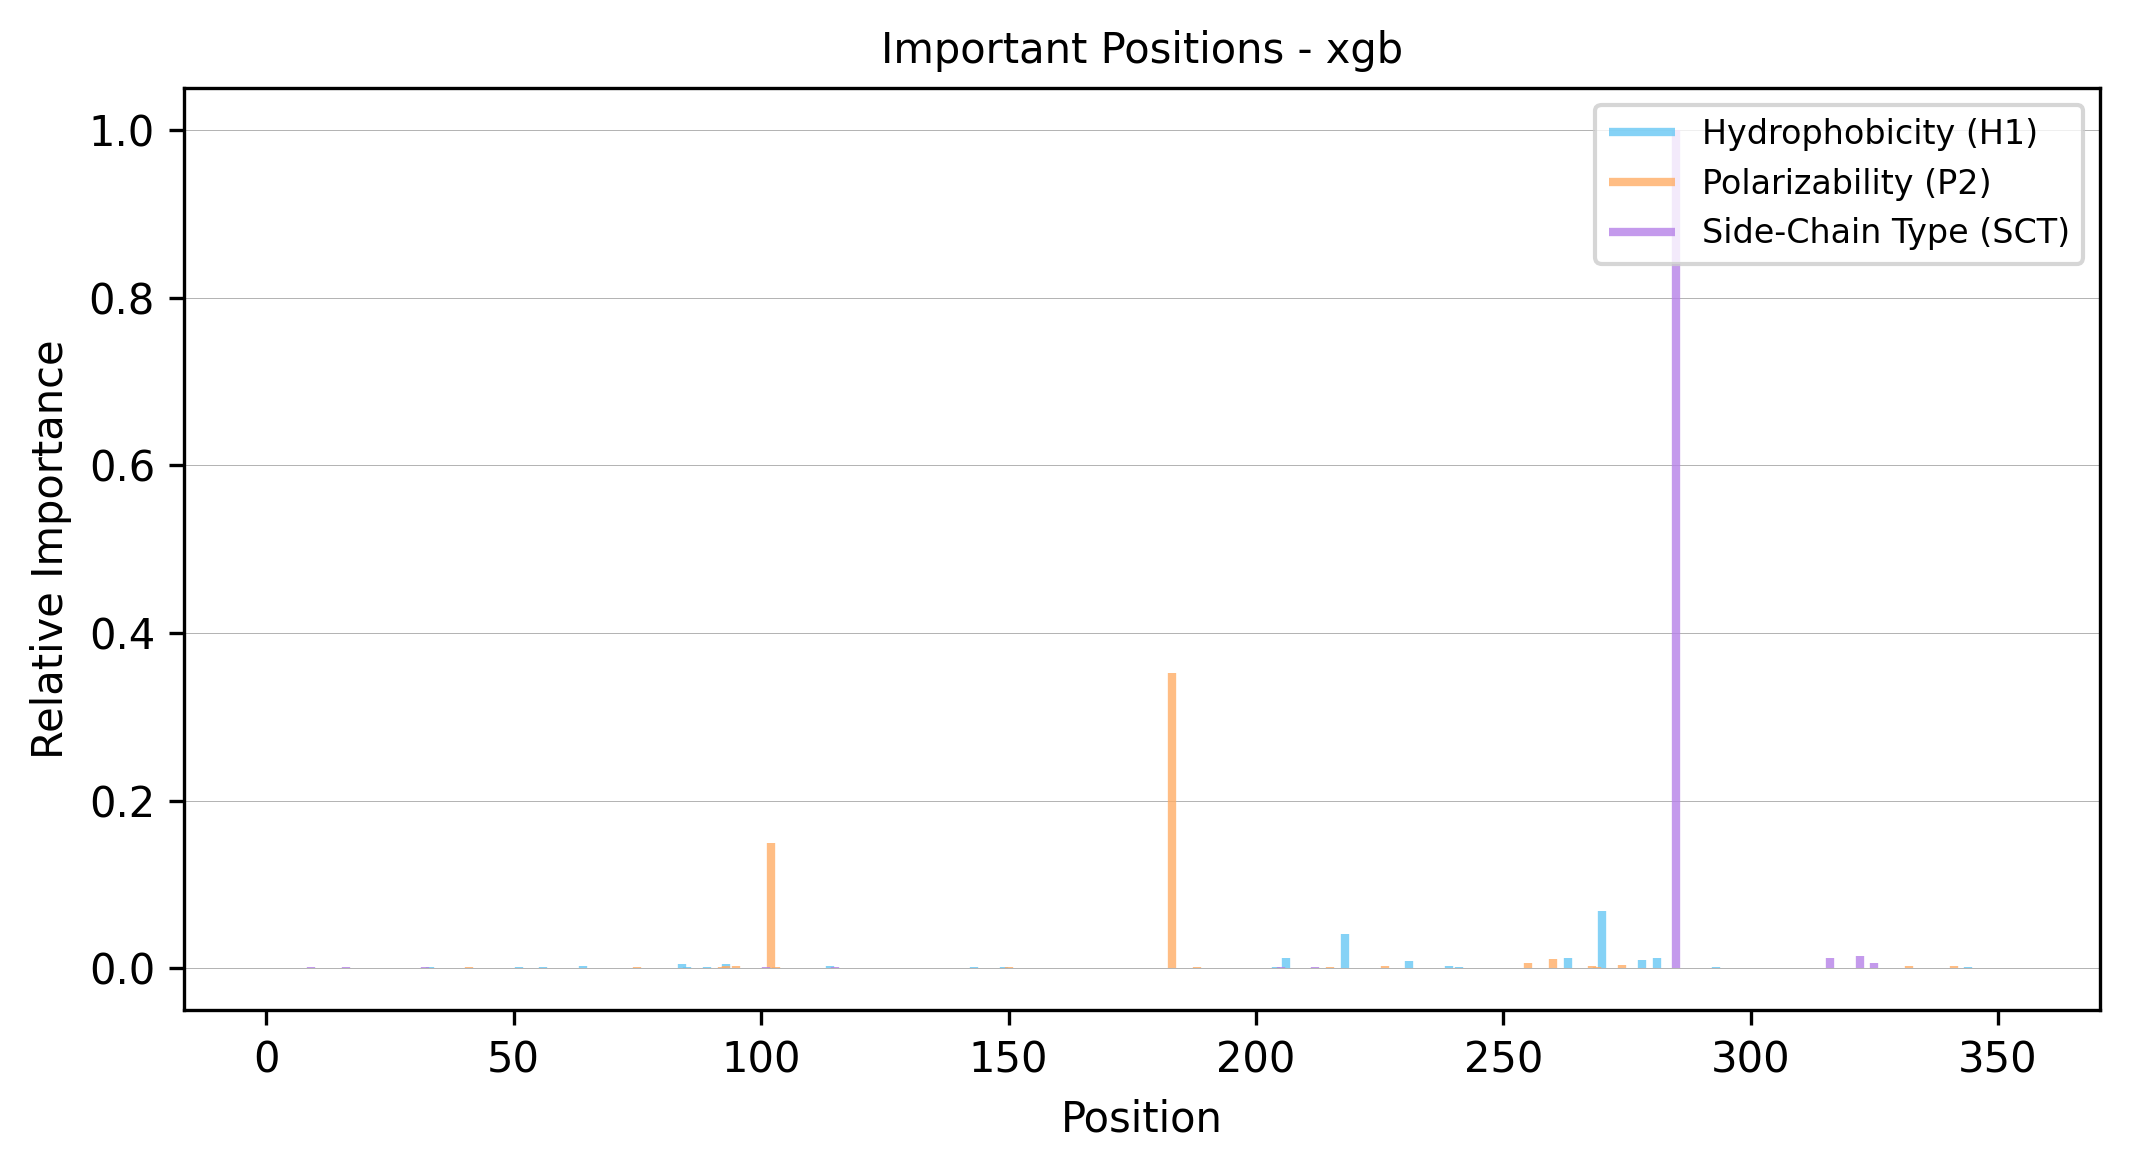

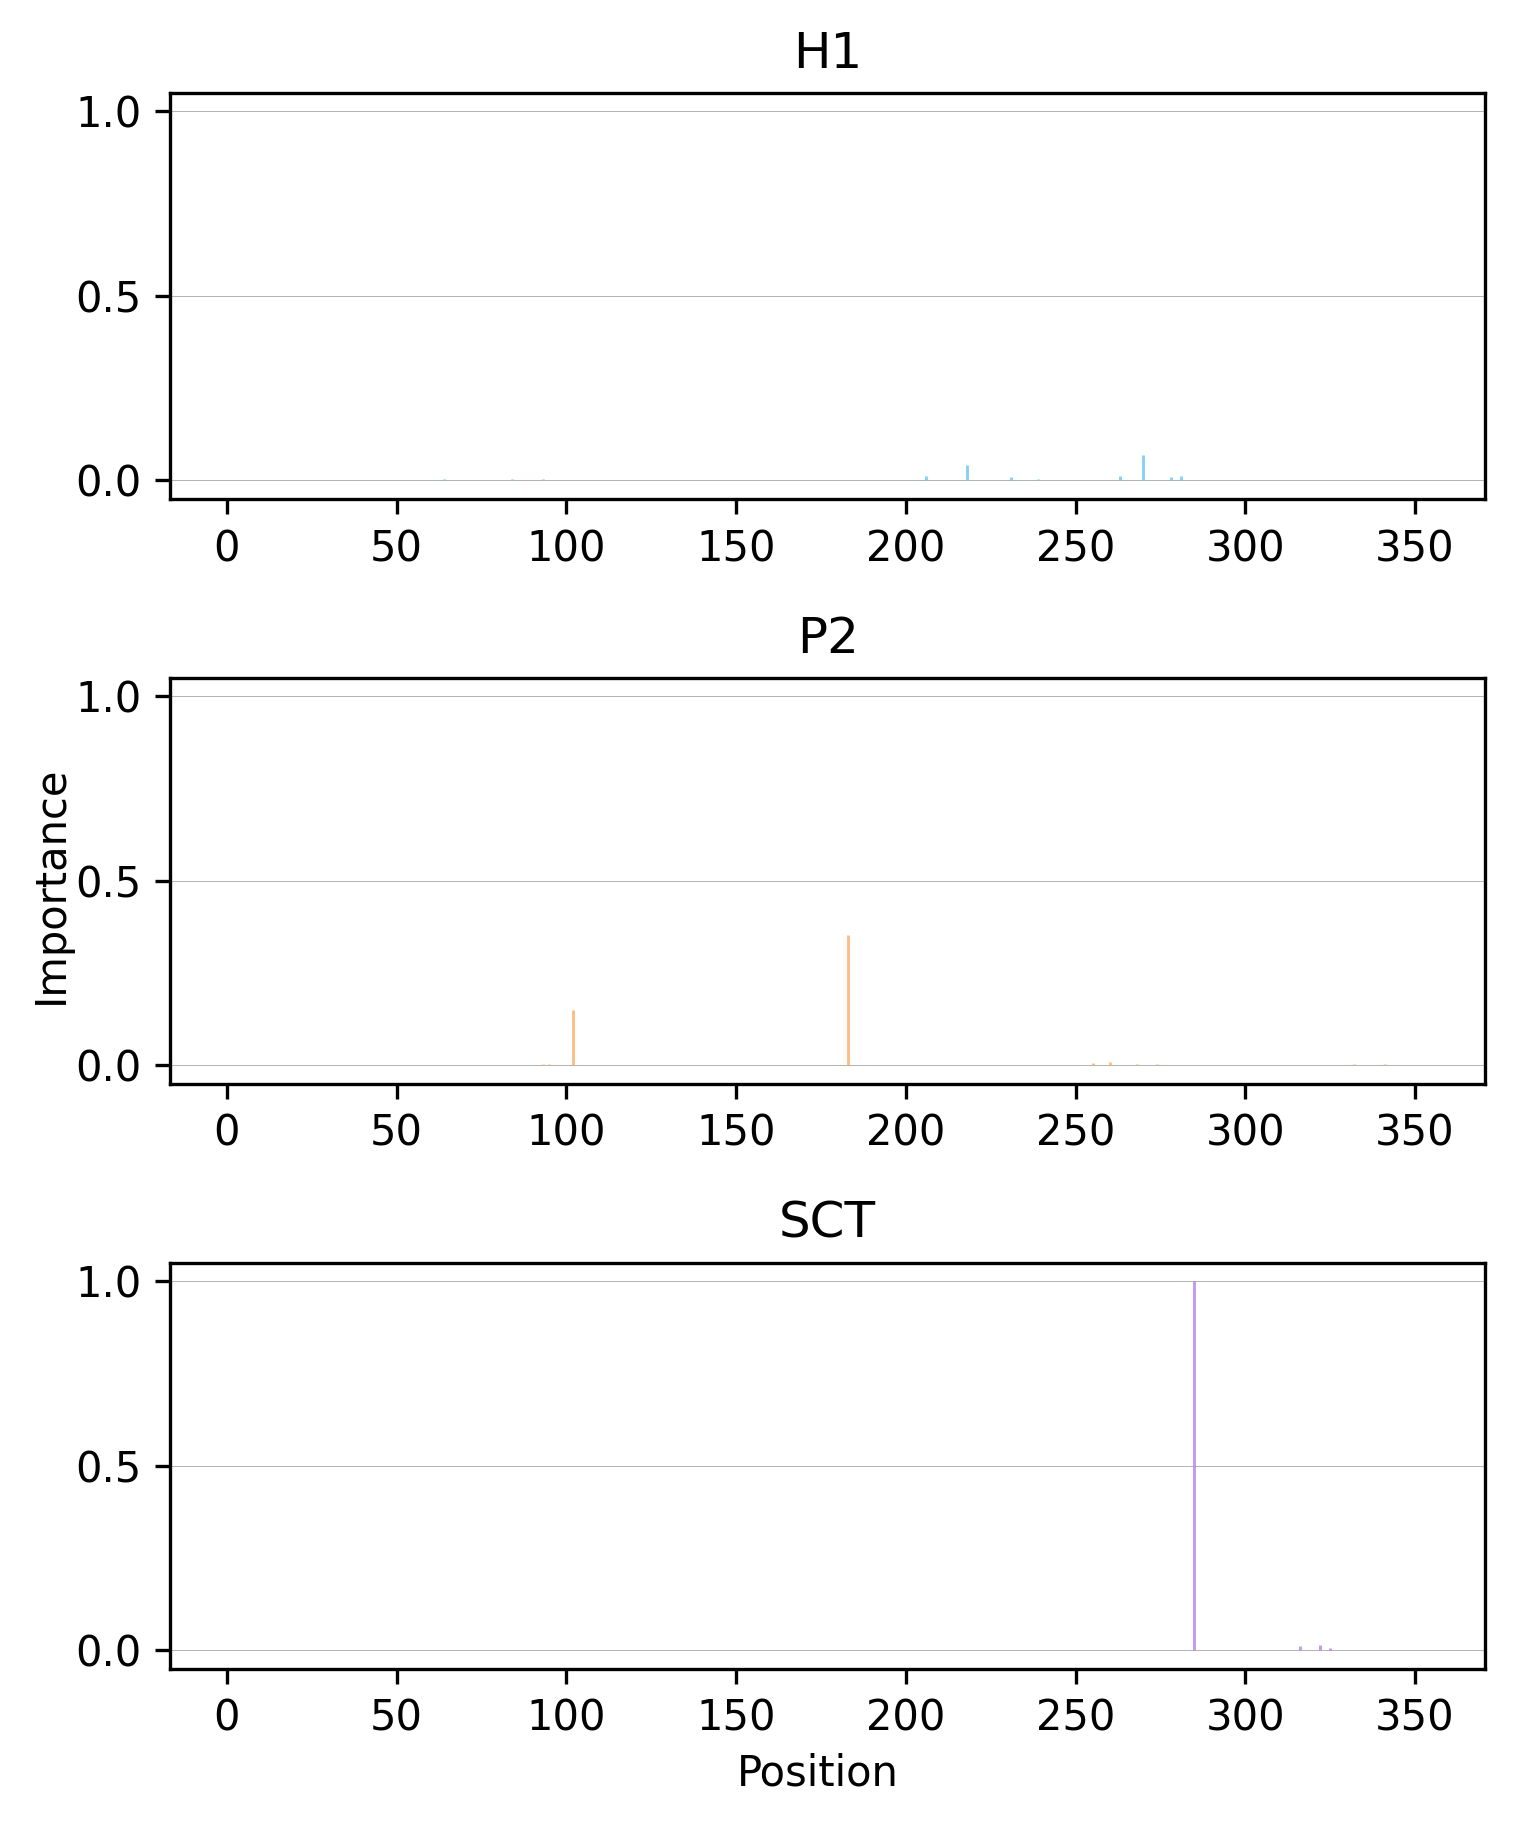

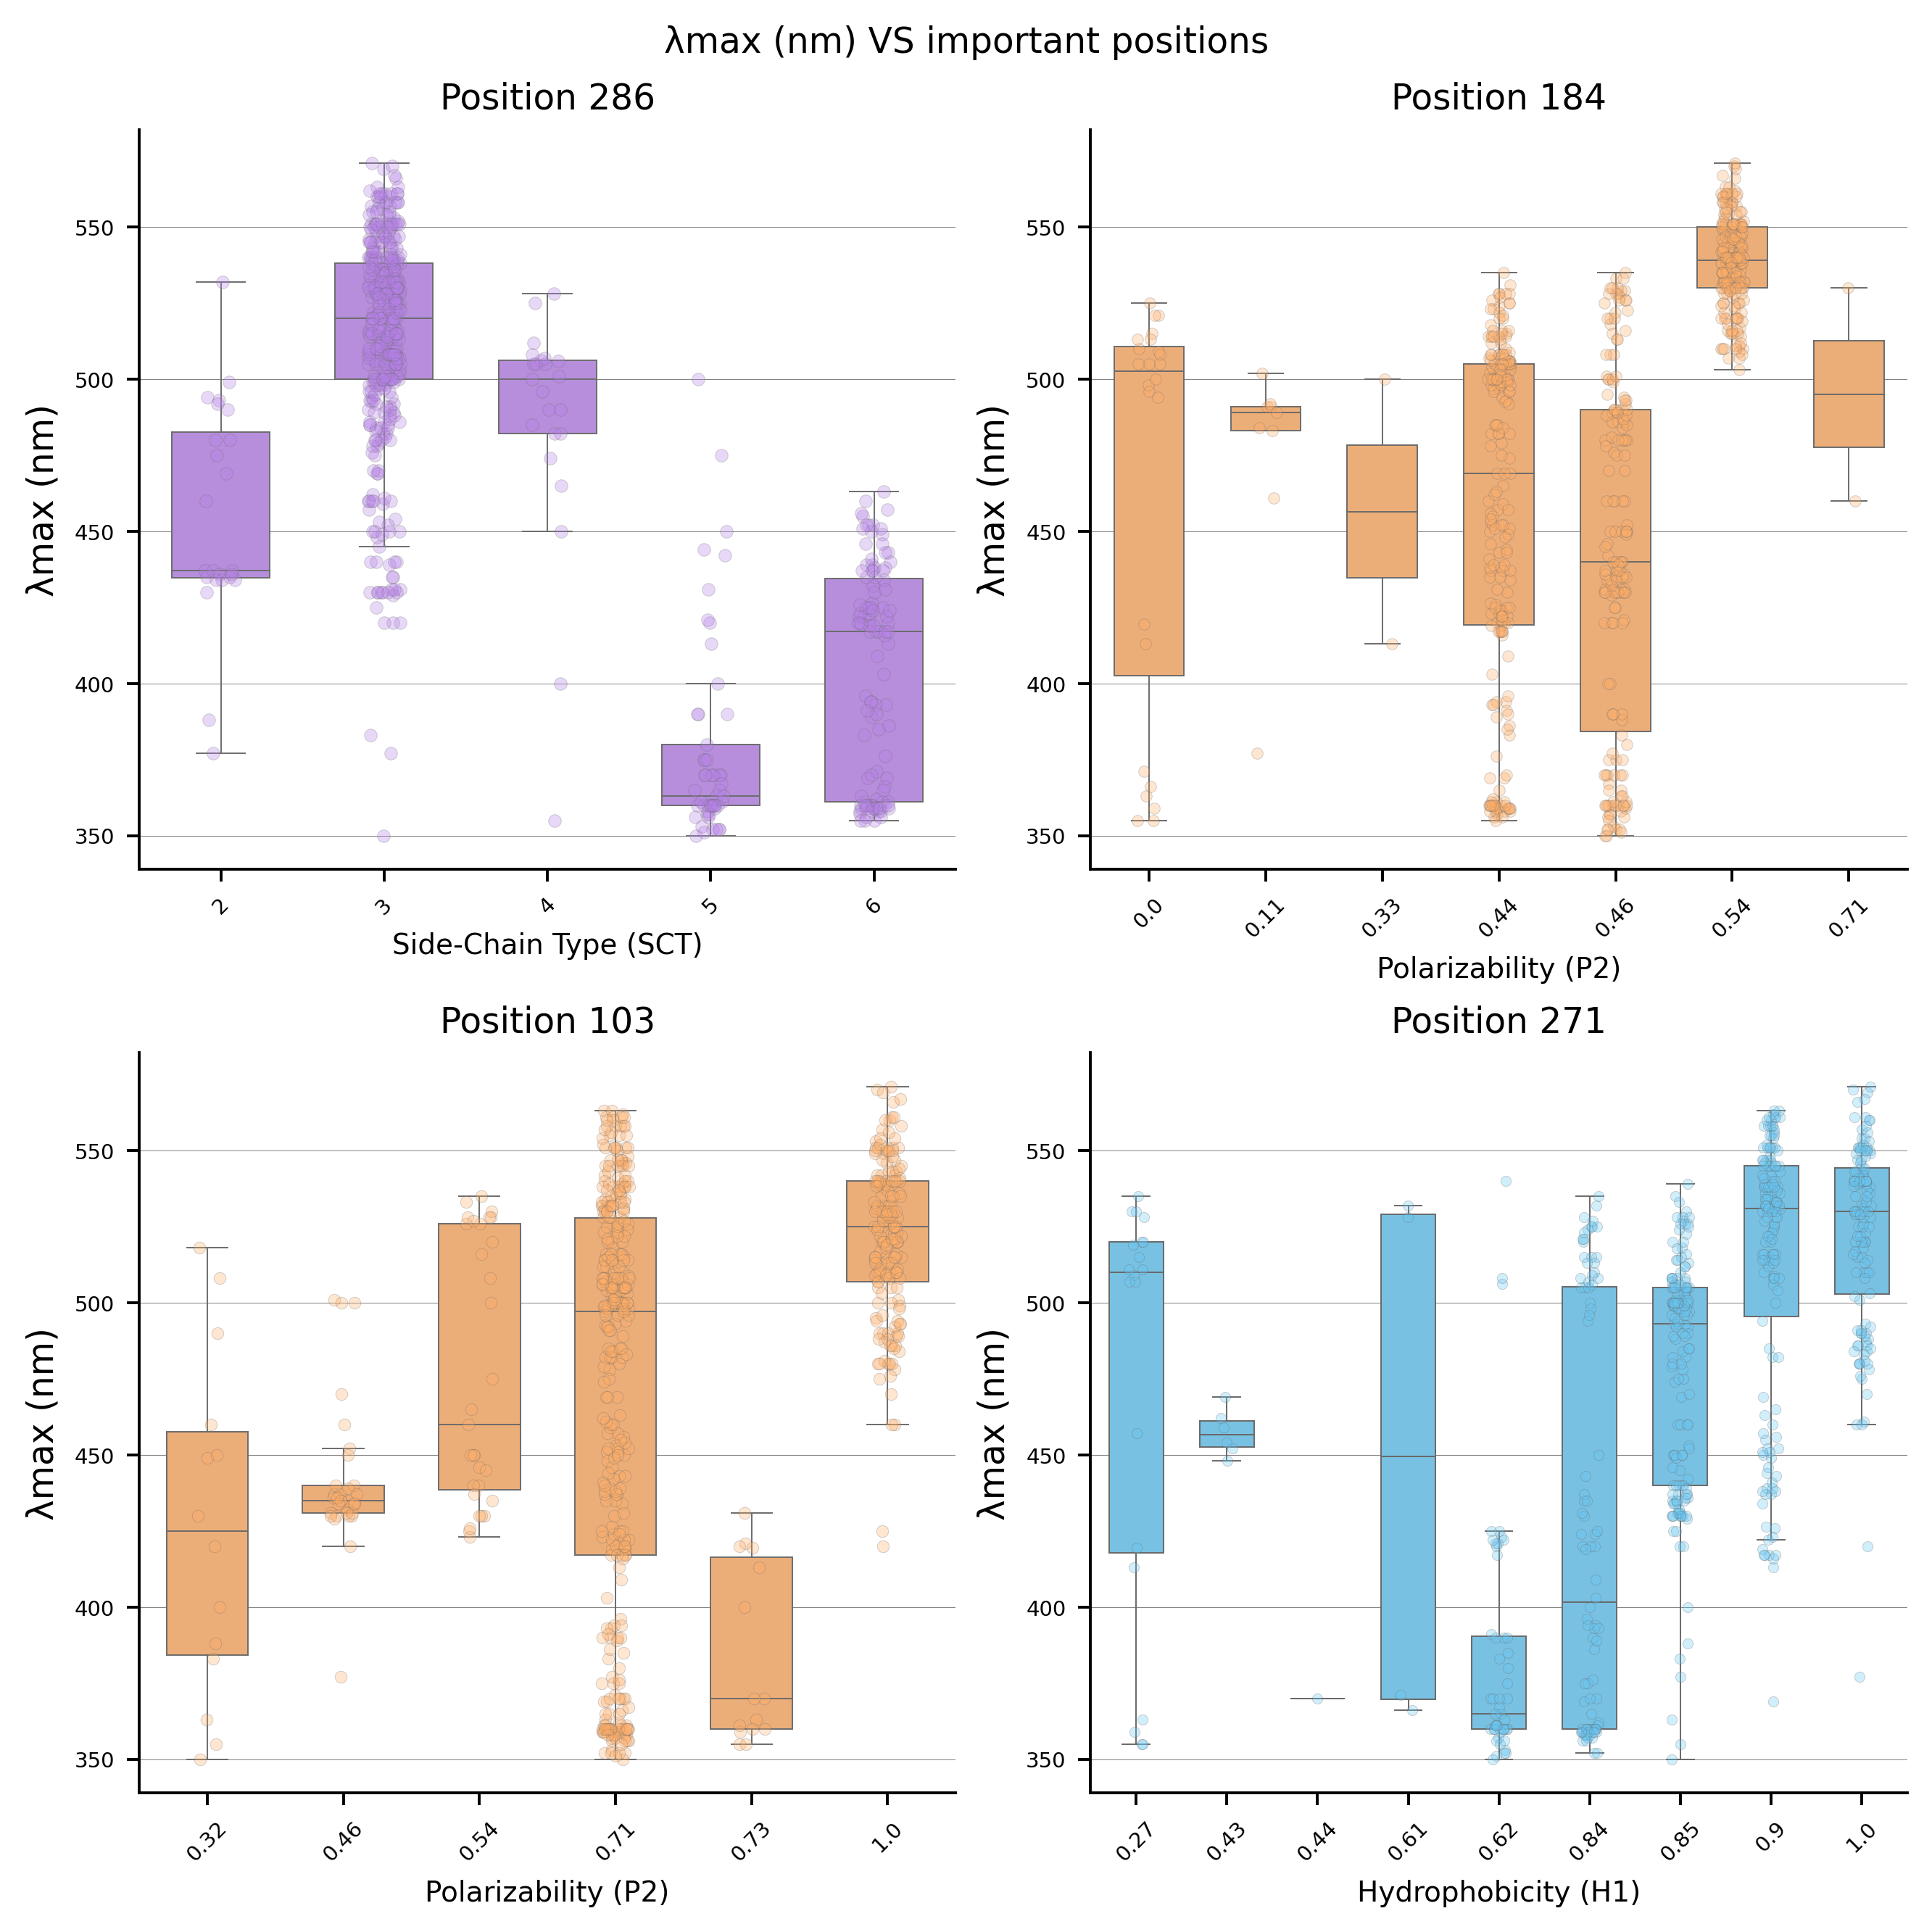

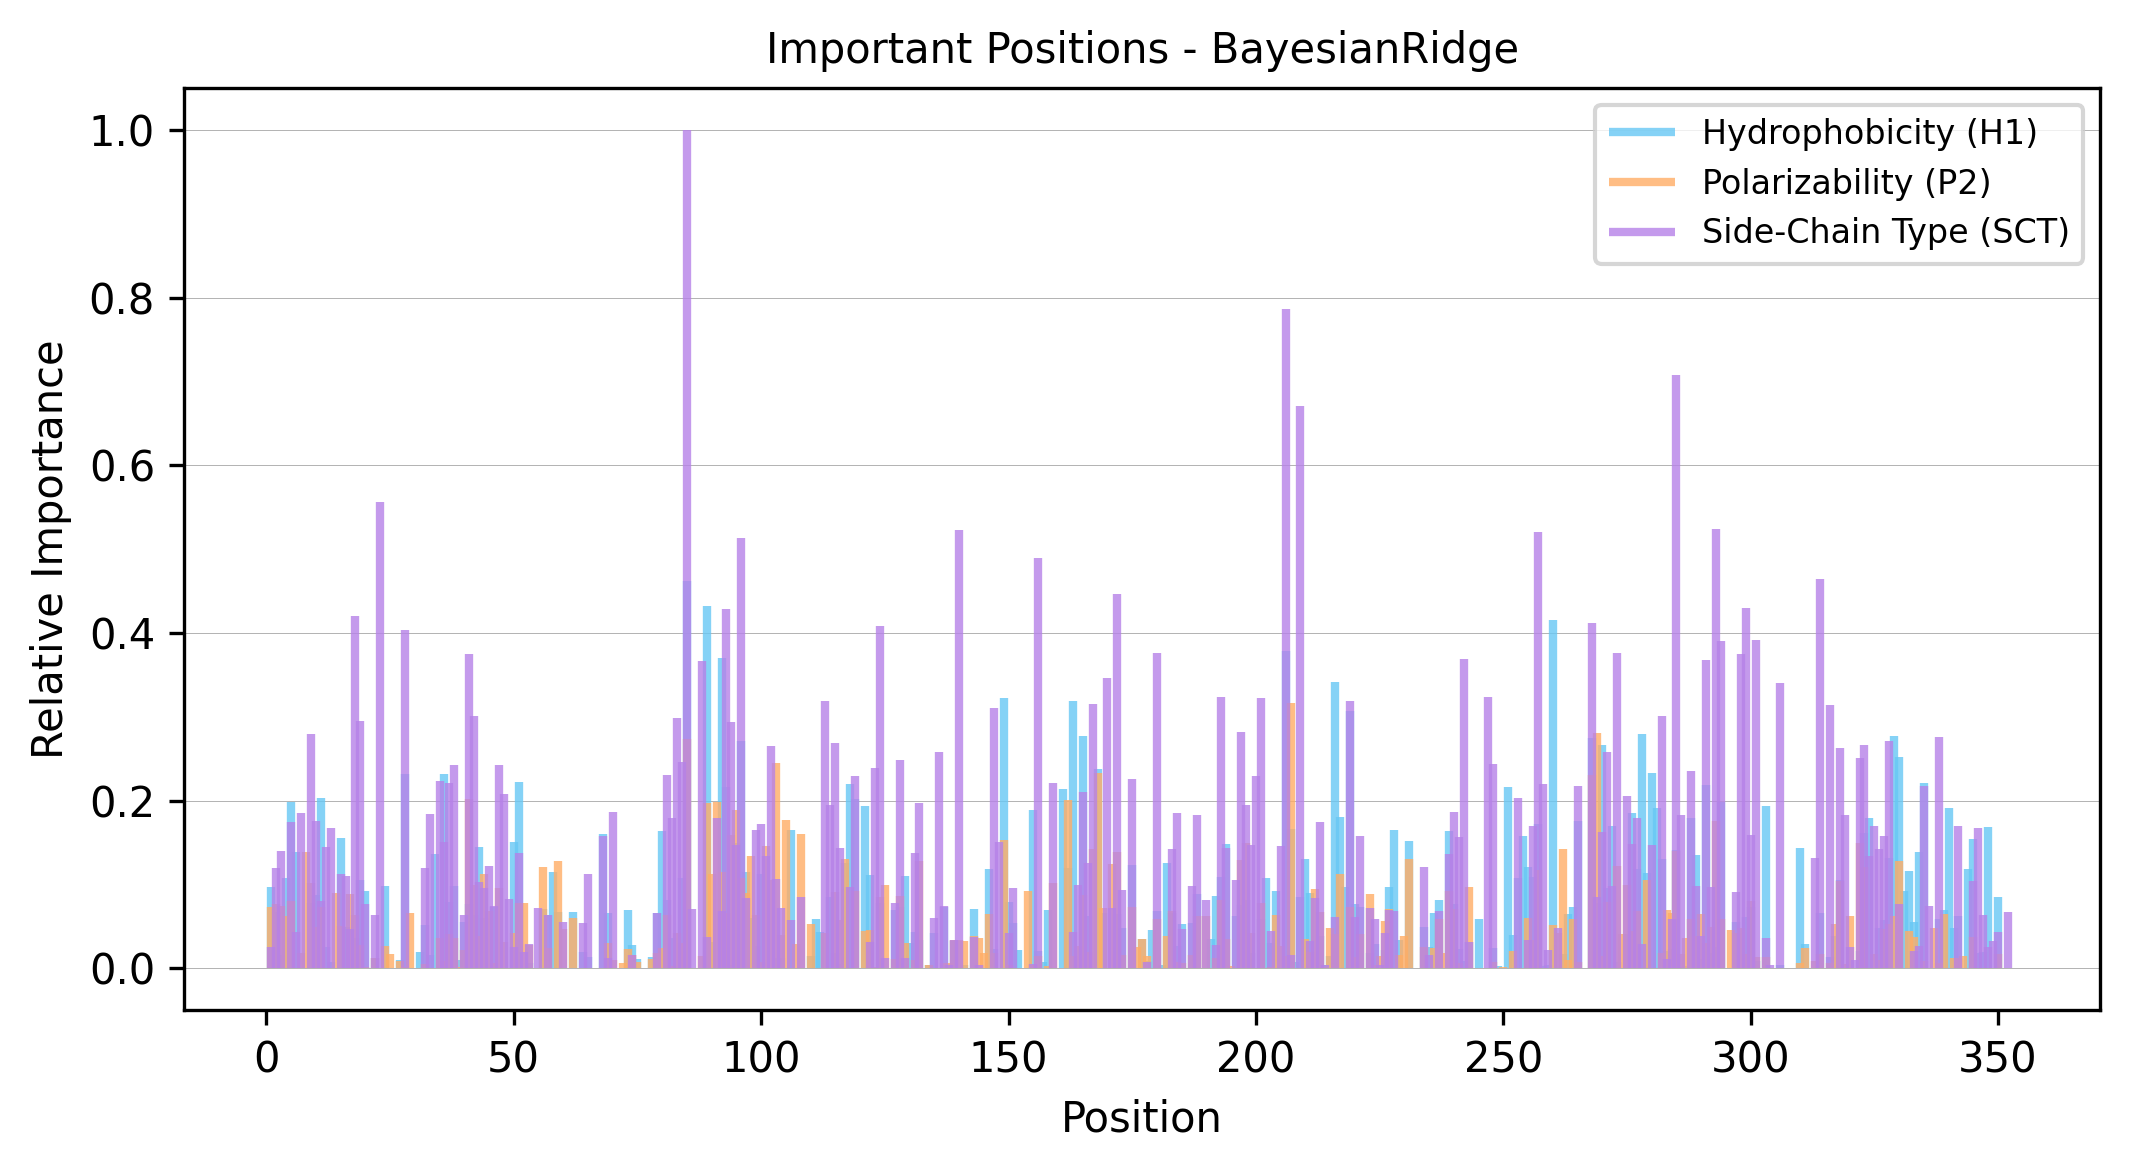

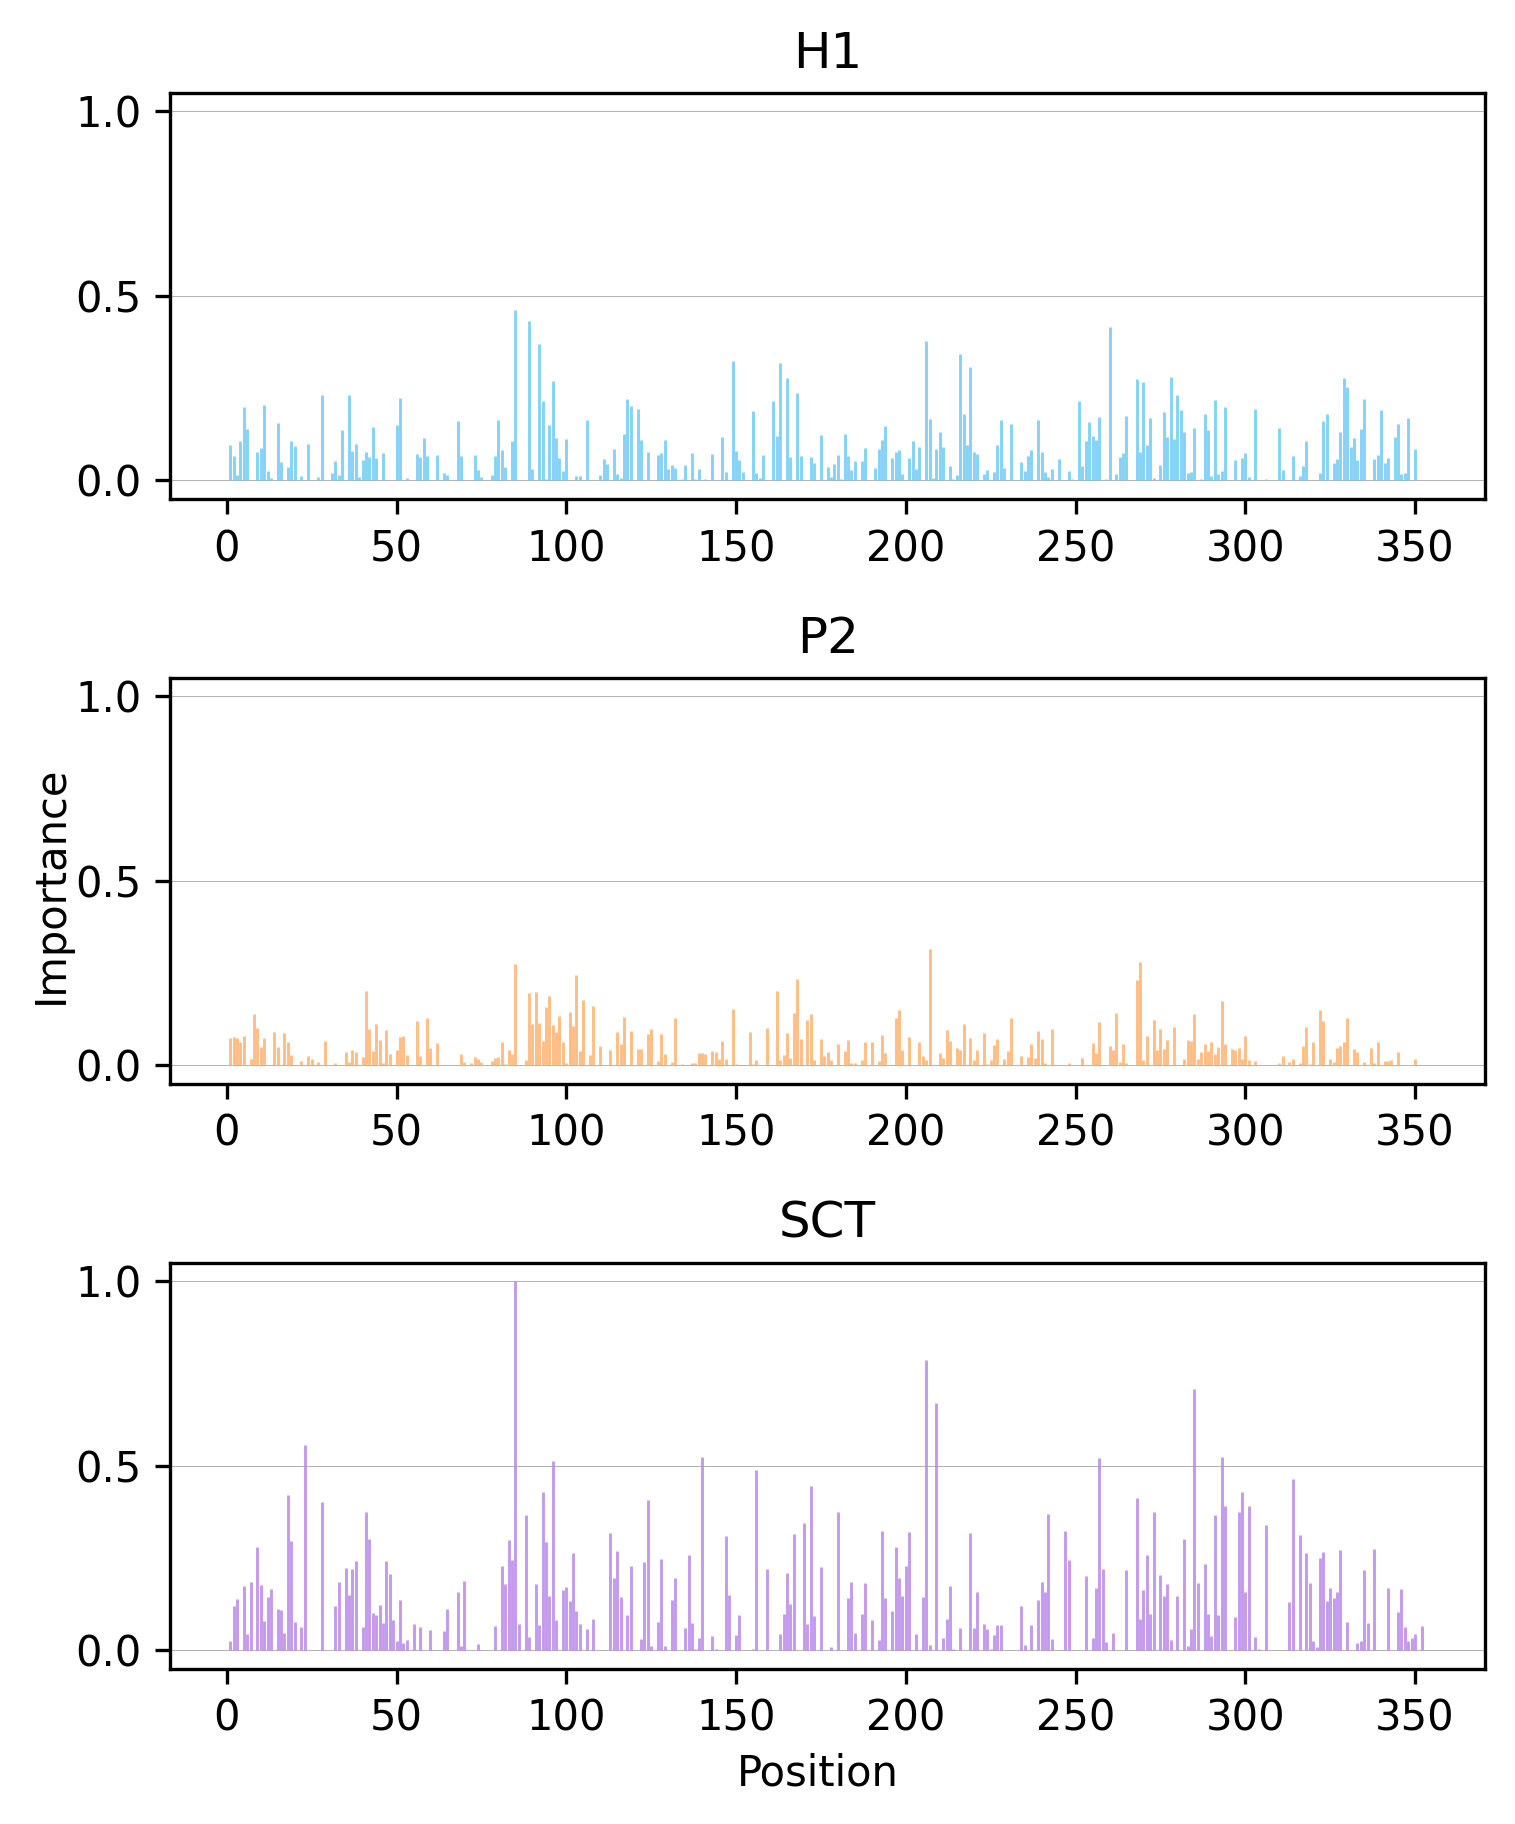

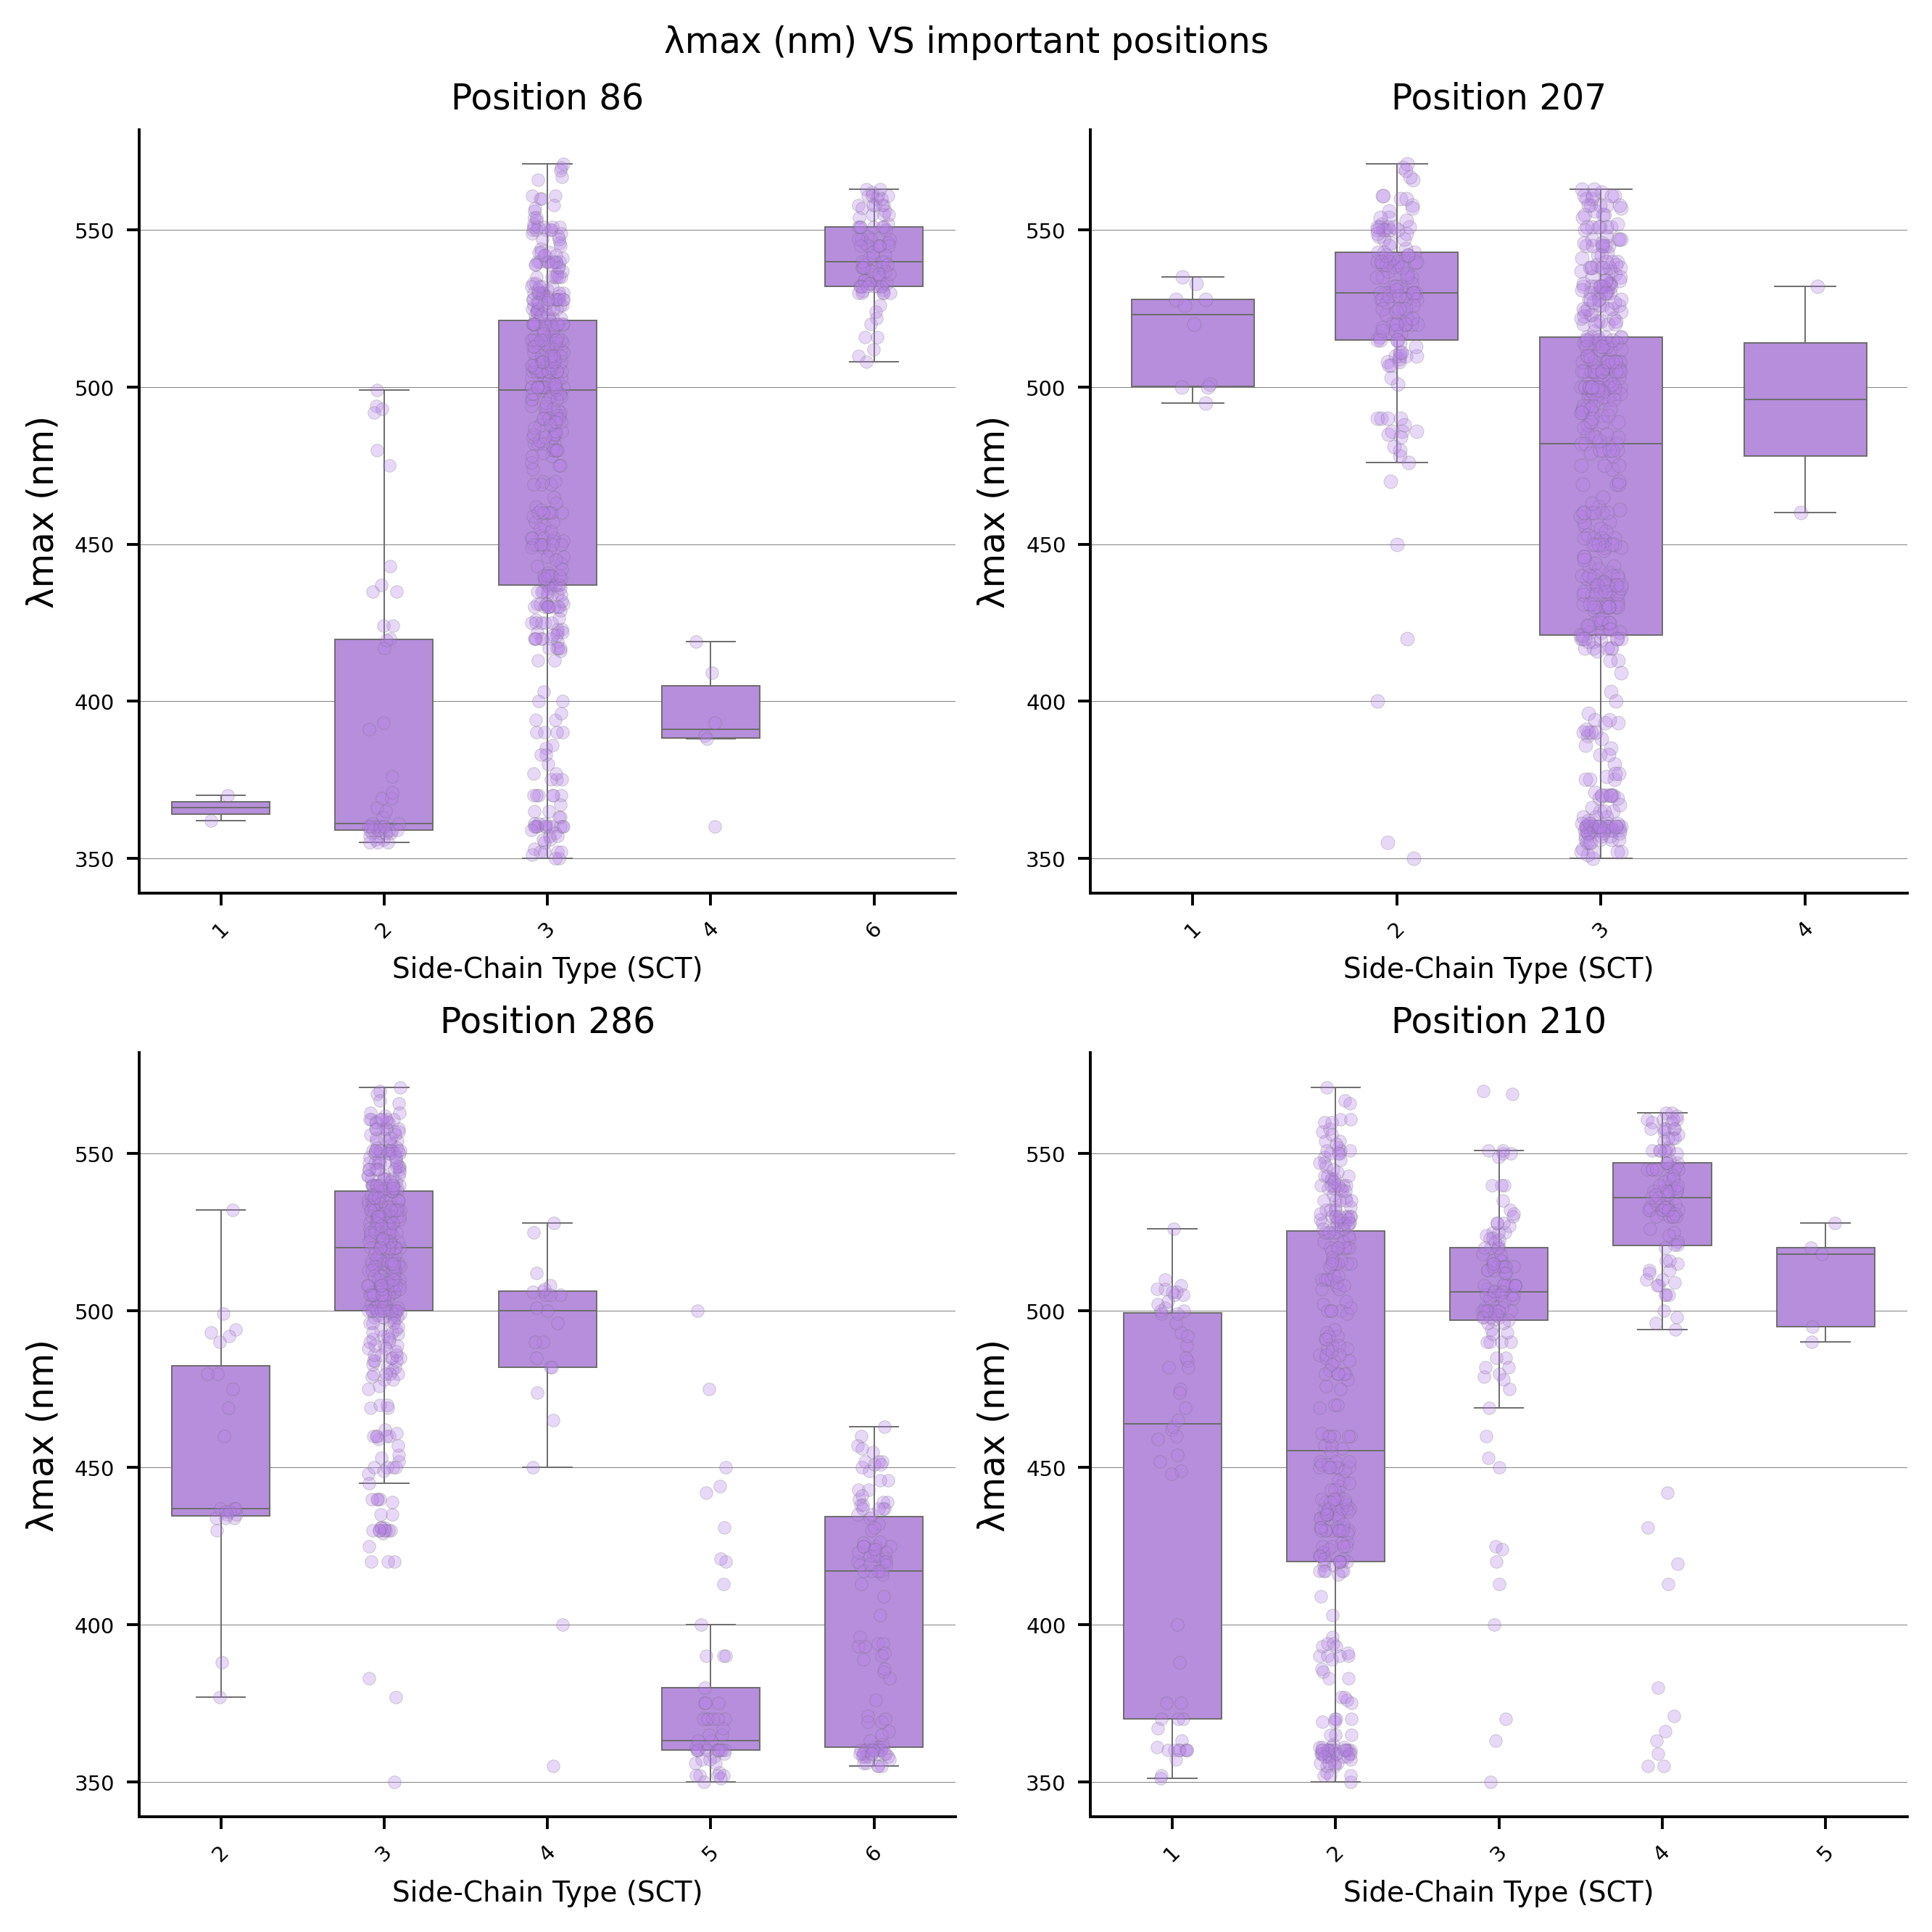

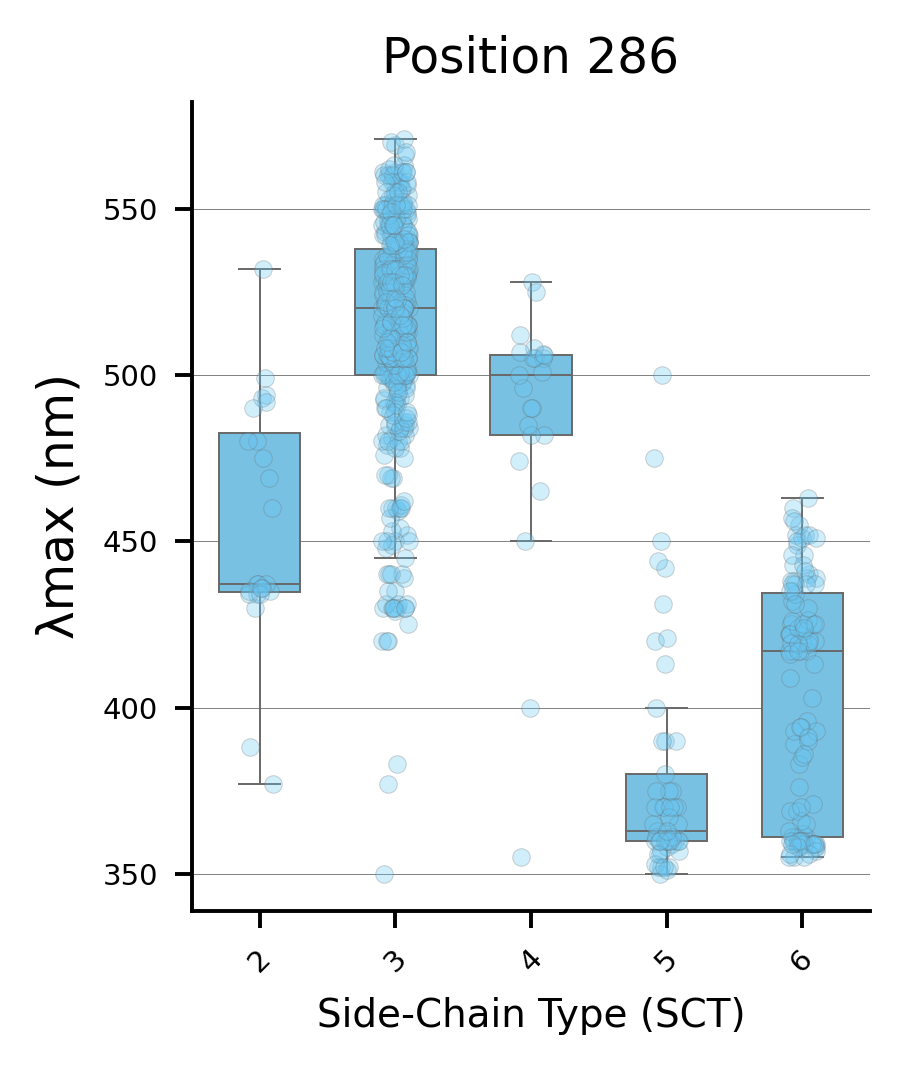

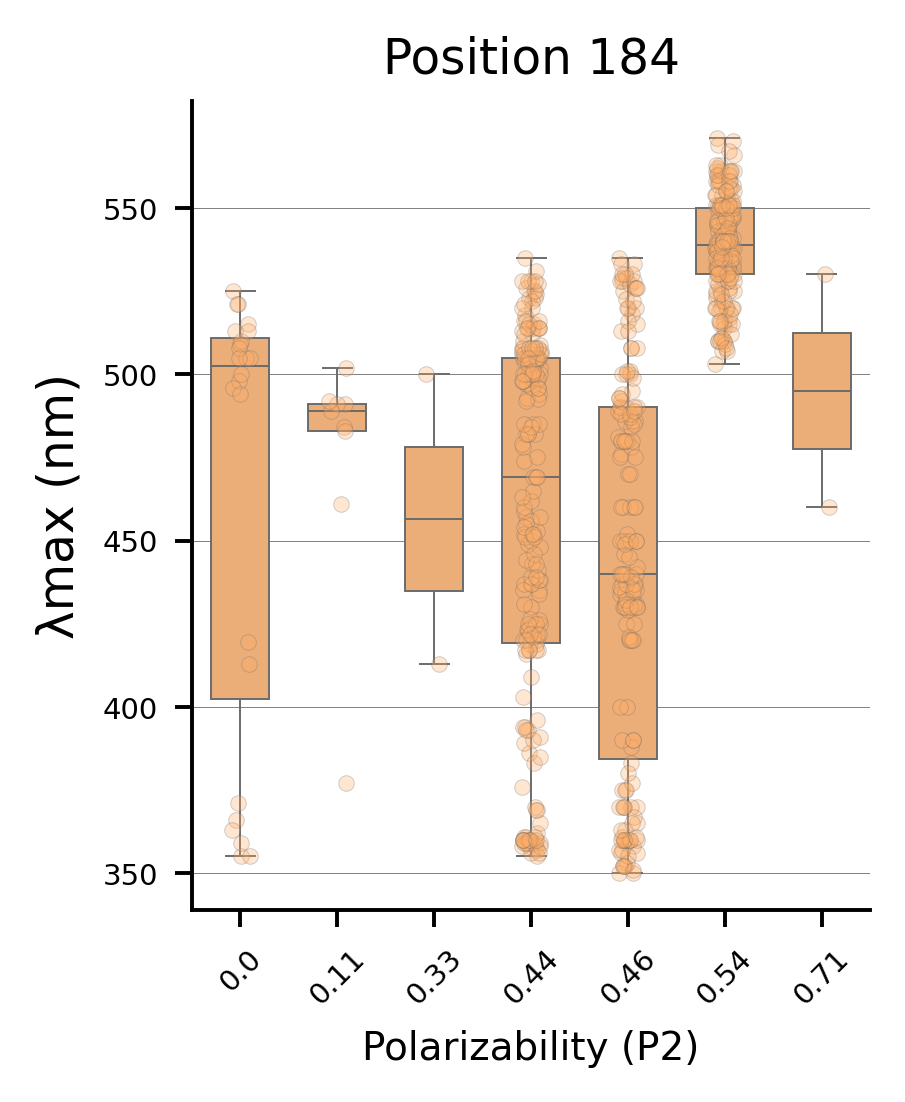

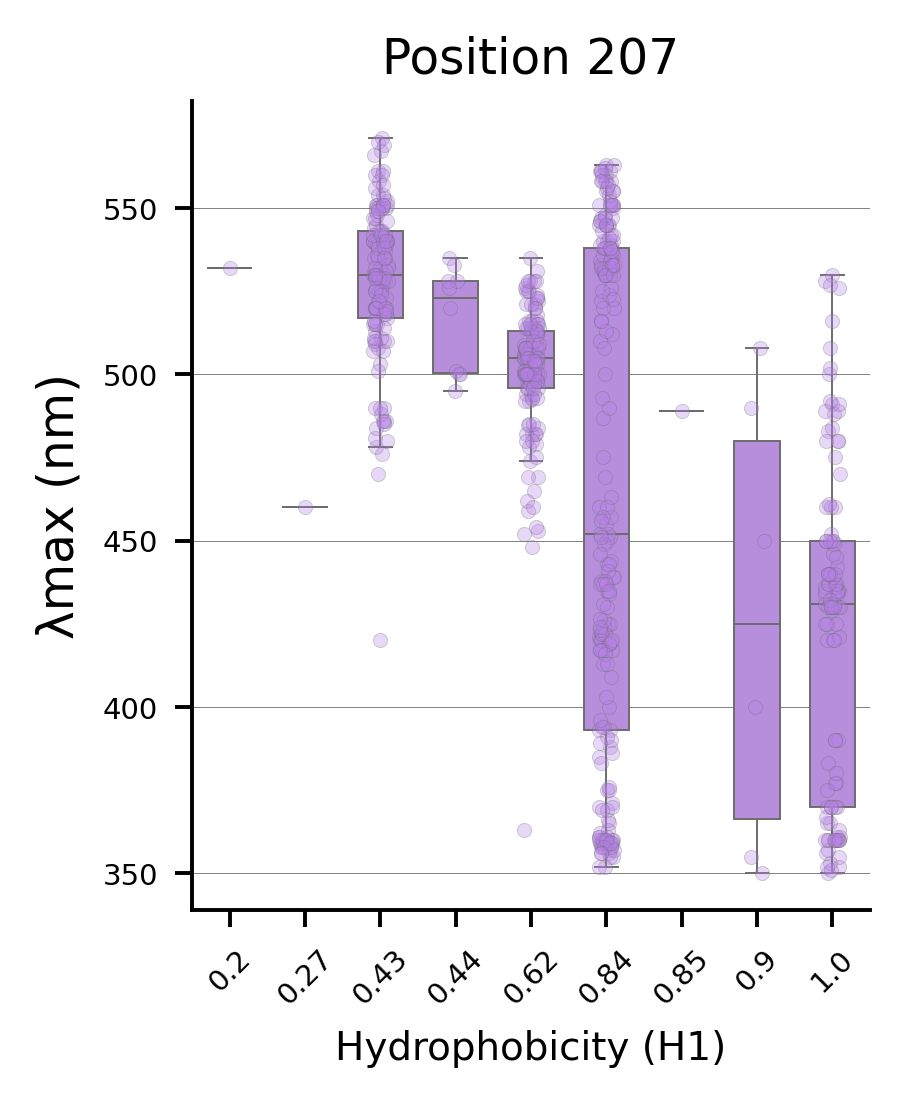

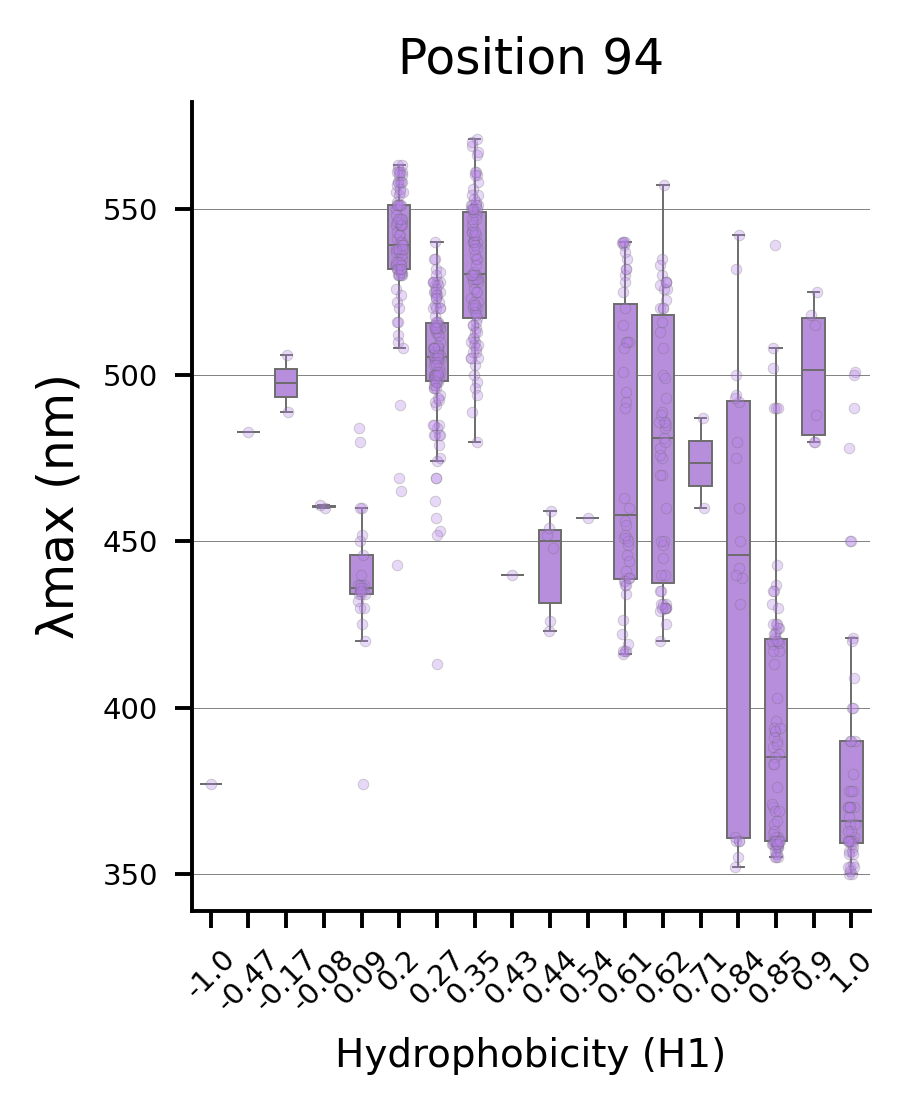

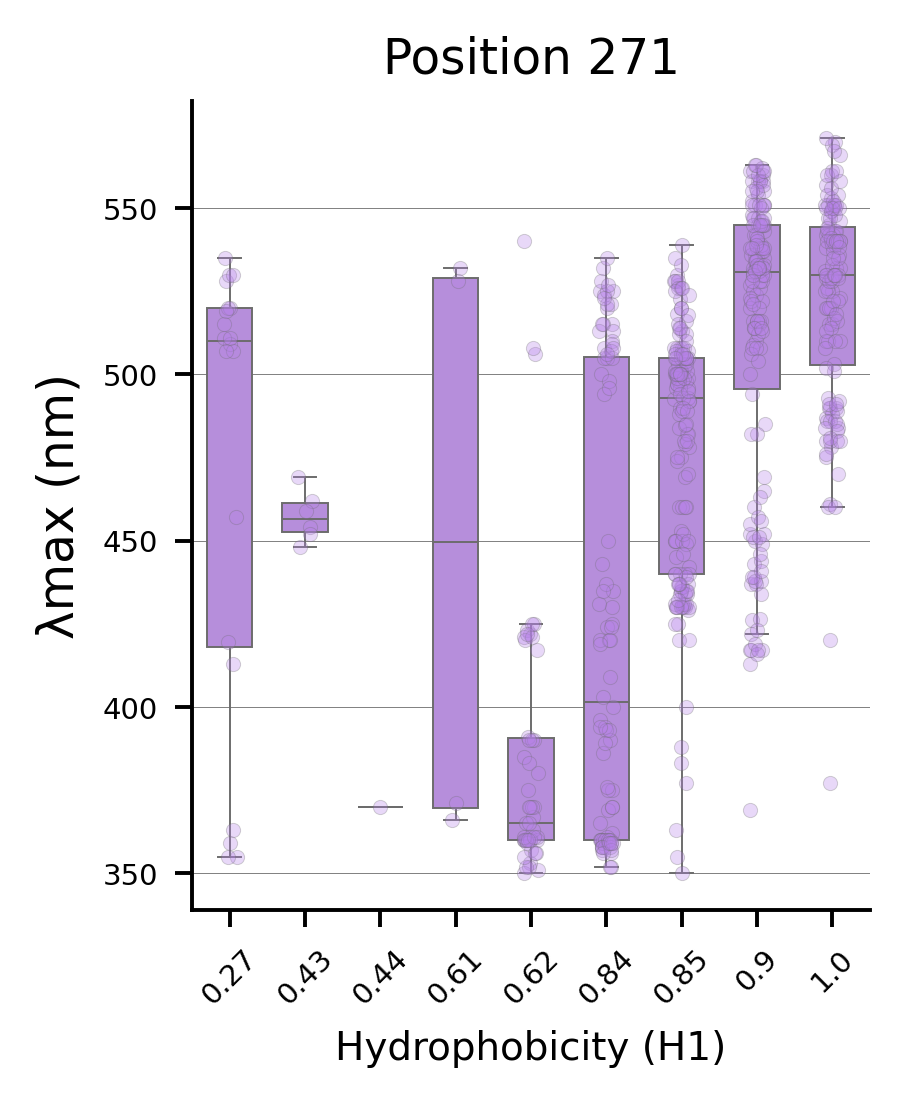

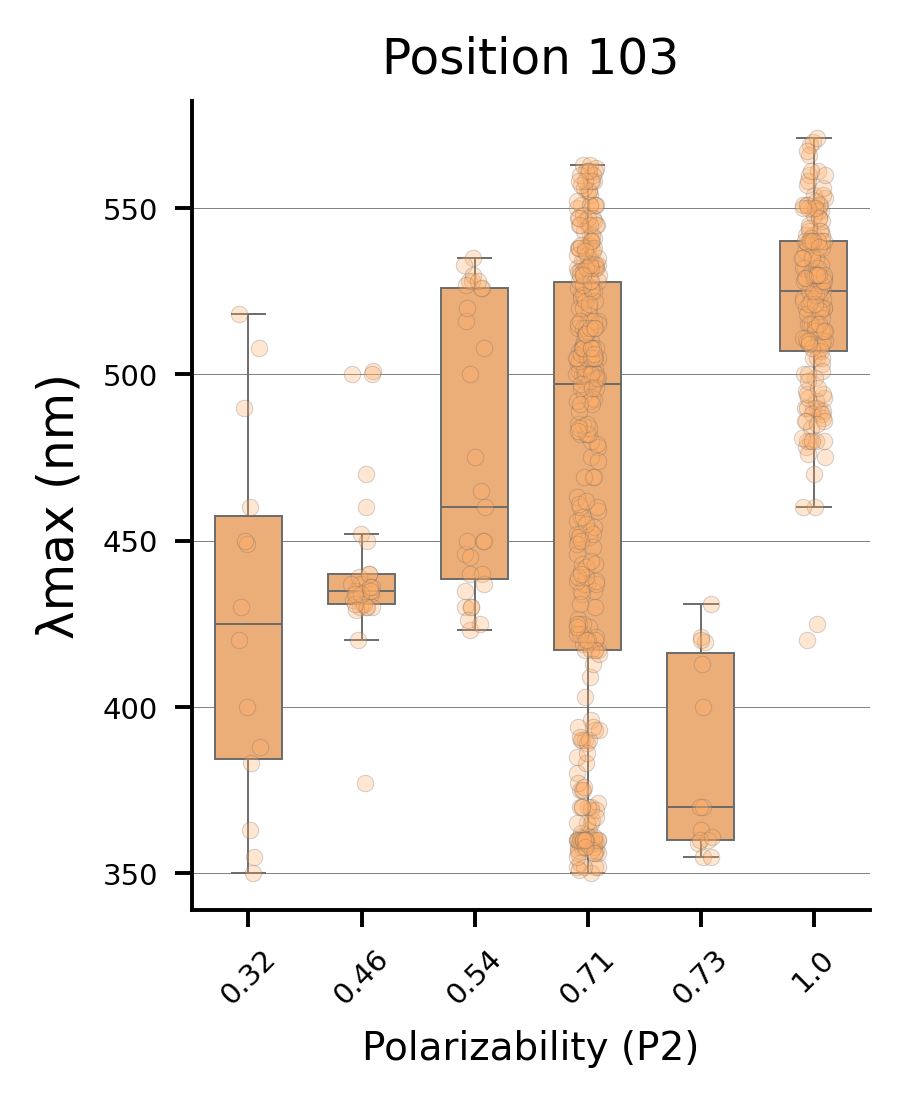

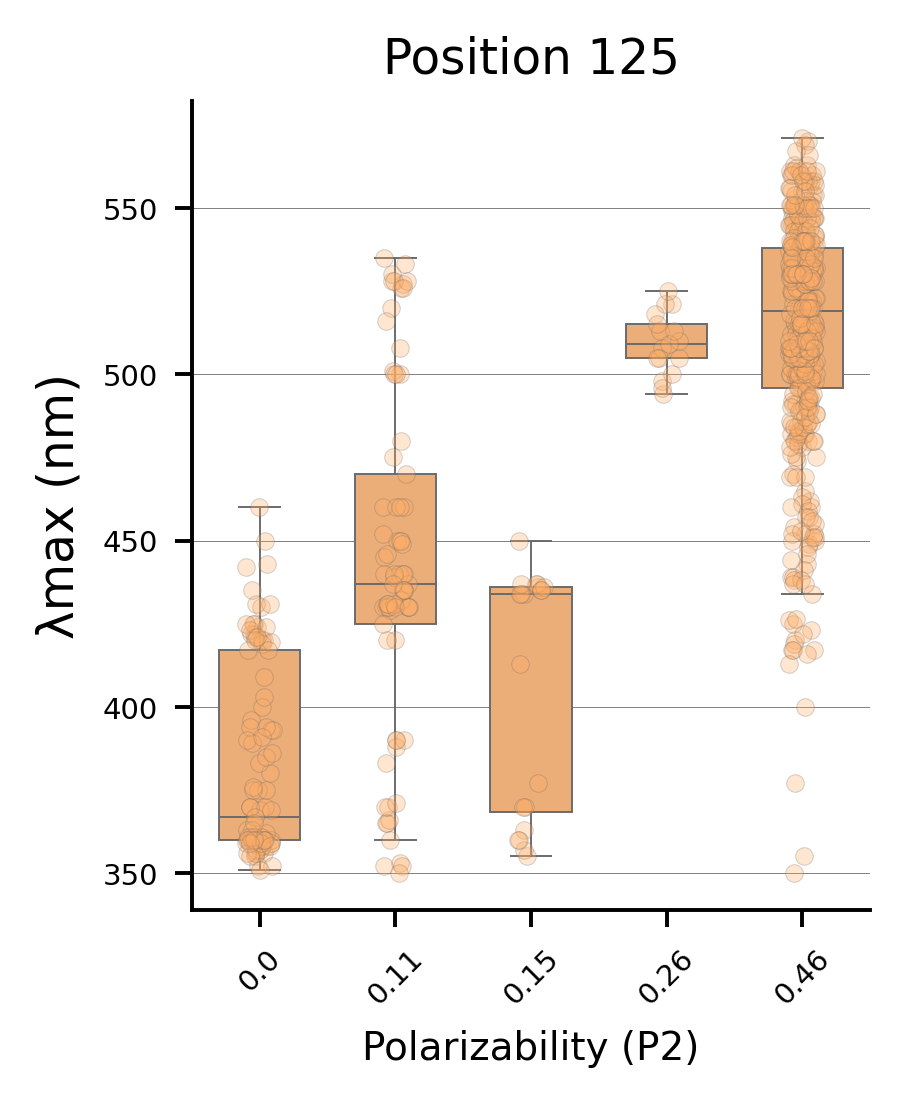

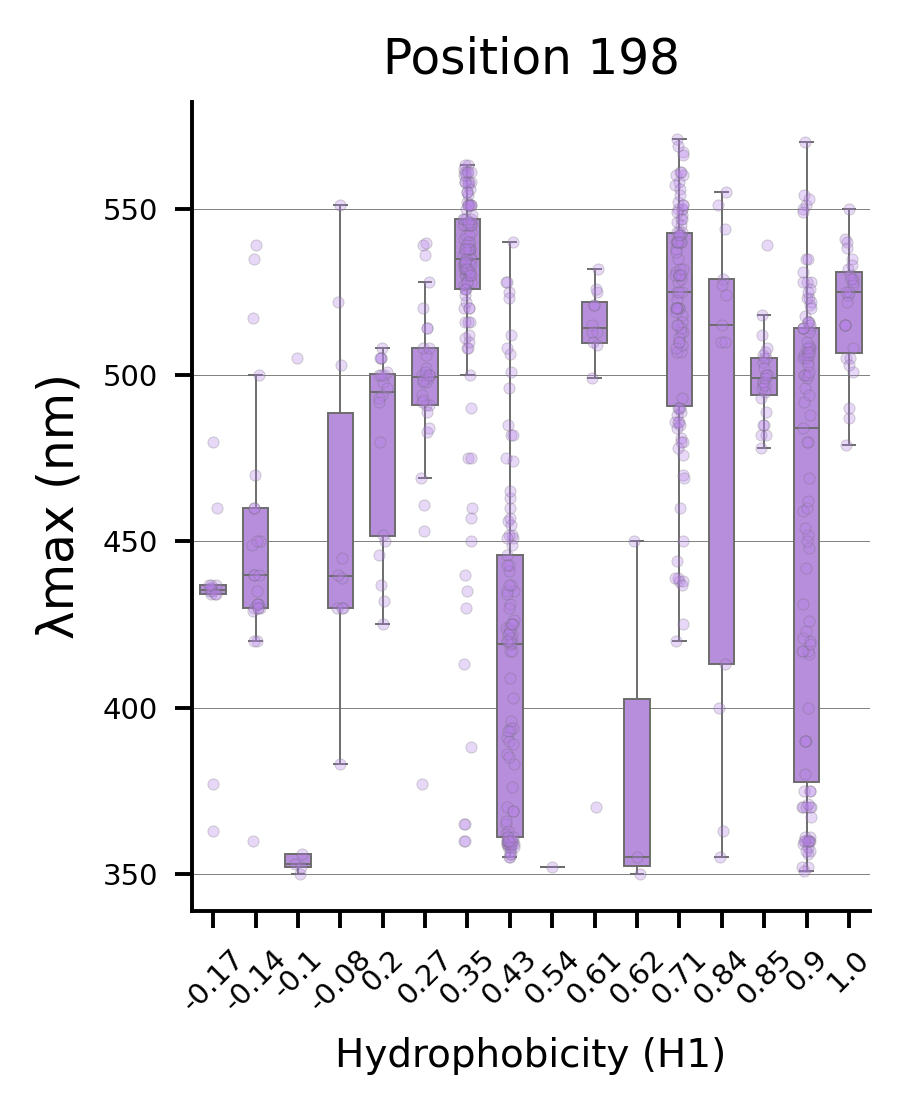

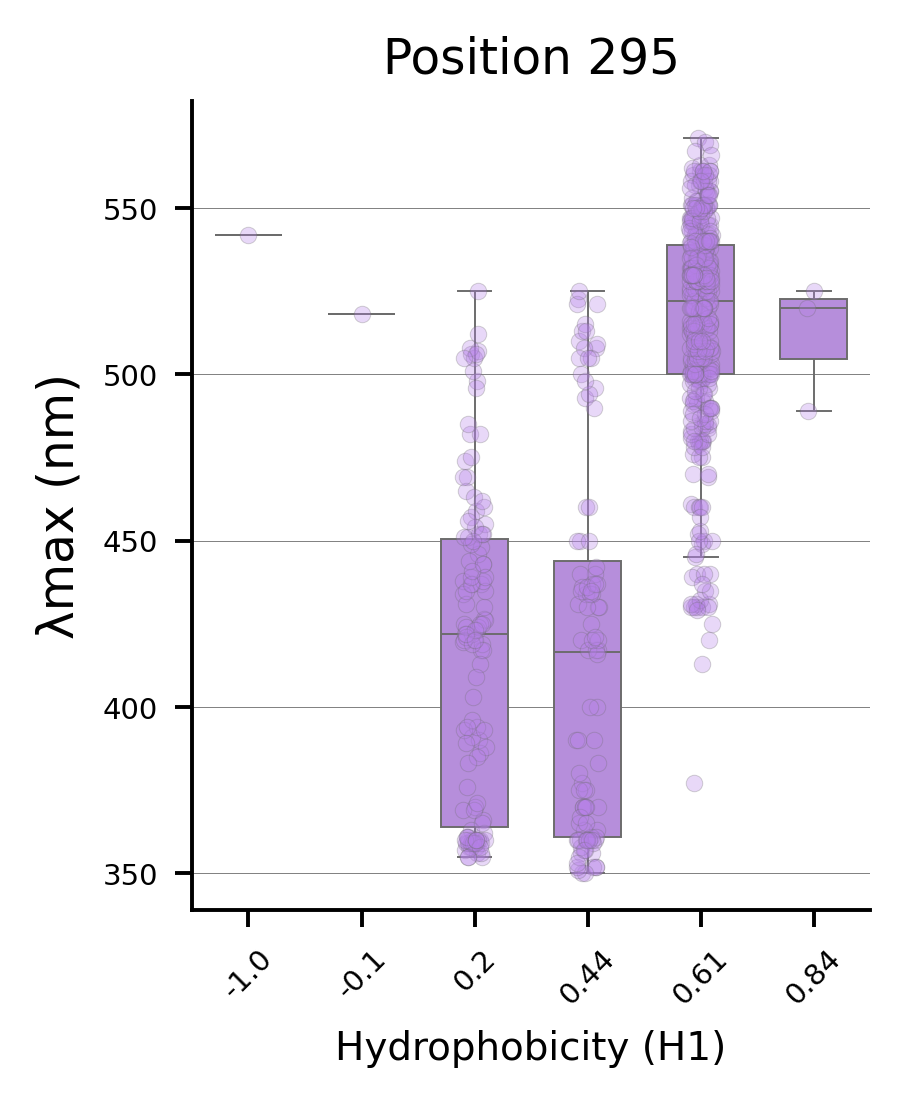

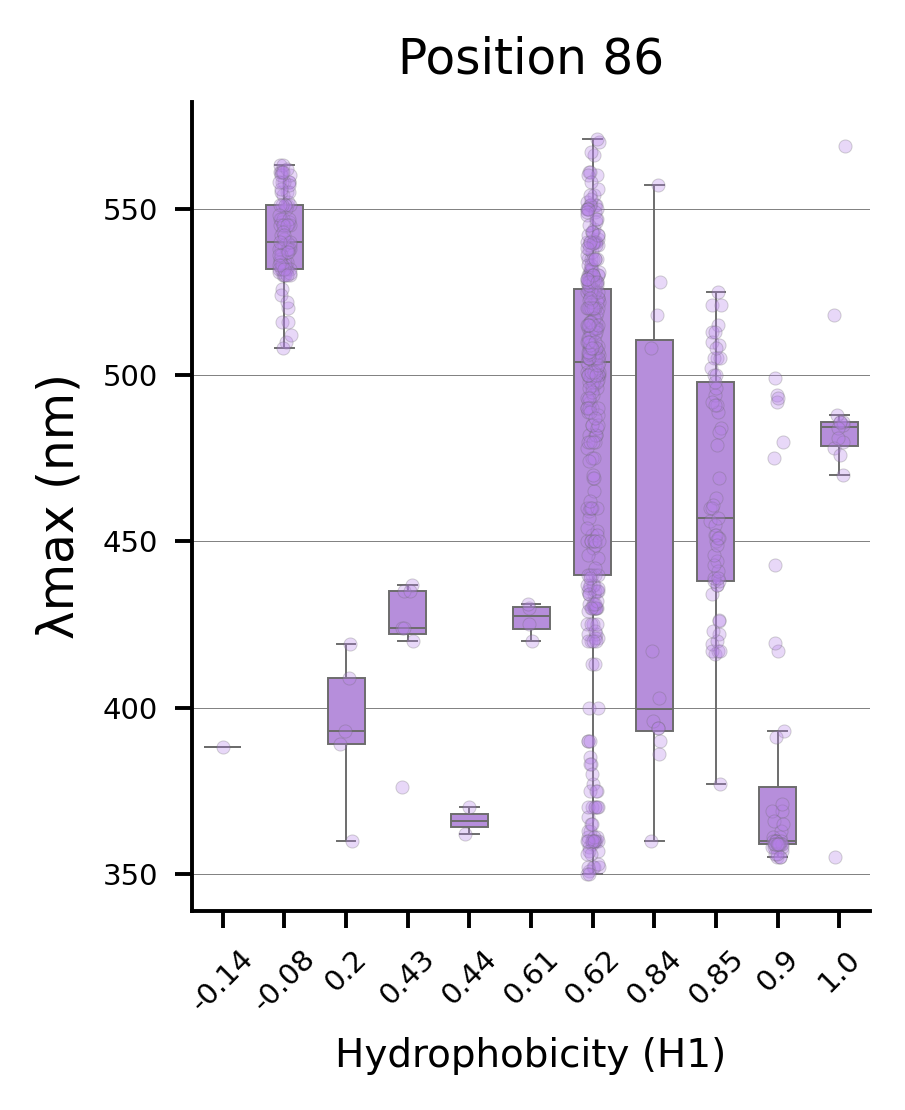

In [50]:
meta_var = "λmax (eV)" if use_ev else "λmax (nm)"

try:
    if encoding_method == "hot":
        encoded_seqs = prep_pipeline[:4].fit_transform(tr)
        for model in top:
            model_name = model.steps[-1][0]
            dp_plot(importance=importance_from_pipe(model), imp_col="standard_value", model_name=model_name, report_dir=str(report_dir))
            plot_imp_model(
                importance=importance_from_pipe(model),
                X_train=encoded_seqs,
                y_train=y,
                model_name=model_name,
                meta_var=meta_var,
                model_type=ana_type,
                report_dir=str(report_dir),
                trans_imp_report=trans_imp_report,
                prop_list=props_to_keep,
            )
        plot_imp_all(final_models=top, X_train=tr, y_train=y, model_type=ana_type, report_dir=str(report_dir), max_plots=10, figsize=(2.5, 3), meta_var=meta_var, trans_imp_report=trans_imp_report)

    elif encoding_method == "aa_prop":
        for model in top:
            encoded_seqs = model.named_steps["prep"]["aa_prop"].aa_encoded_seqs_
            model_name = model.steps[-1][0]
            dp_aa_prop_plot(importance=aaprop_importance_from_pipe(model), imp_col="standard_value", model_name=model_name, report_dir=str(report_dir), props_to_keep=props_to_keep)
            plot_imp_model(
                importance=aaprop_importance_from_pipe(model),
                X_train=encoded_seqs,
                y_train=y,
                model_name=model_name,
                meta_var=meta_var,
                model_type=ana_type,
                report_dir=str(report_dir),
                trans_imp_report=trans_imp_report,
                prop_list=props_to_keep,
            )
        plot_imp_all(final_models=top, X_train=encoded_seqs, y_train=y, model_type=ana_type, report_dir=str(report_dir), max_plots=10, figsize=(2.5, 3), meta_var=meta_var, trans_imp_report=trans_imp_report)
except Exception as exc:
    print("Importance plotting failed; check model-specific pipeline output.")
    print(exc)